# Irrelevant memory RSA

Goal: prototype item-level RSA for recognized irrelevant old images.

Main contrast of interest:
- true_week
- schema_week

Initial scope:
- one subject
- post-viewing only
- ROI-based patterns

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn import image, plotting, datasets
from nilearn.glm.first_level import FirstLevelModel
from nilearn.maskers import NiftiMasker

from scipy.spatial.distance import pdist, squareform
from scipy.stats import ttest_1samp, wilcoxon

# --------------------------------------------------
# Project paths
# --------------------------------------------------

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")

BIDS_DIR = PROJECT_ROOT / "data" / "bids_ackbar"
FMRIPREP_DIR = PROJECT_ROOT / "data" / "fmriprep_output"
LABELS_PATH = PROJECT_ROOT / "data" / "preprocessed" / "irrelevant_seen_old_memory_labels_clean_fmri.csv"

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())
print("BIDS dir exists:", BIDS_DIR.exists(), BIDS_DIR)
print("fMRIPrep dir exists:", FMRIPREP_DIR.exists(), FMRIPREP_DIR)
print("Labels file exists:", LABELS_PATH.exists(), LABELS_PATH)

# --------------------------------------------------
# Analysis parameters
# --------------------------------------------------

sub = "sub-P10"
ses = "ses-05"  # post-viewing
smooth_fwhm = 5.0

print("\nPrototype subject:", sub)
print("Prototype session:", ses)
print("Smoothing FWHM:", smooth_fwhm)

# --------------------------------------------------
# Load behavioral memory labels
# --------------------------------------------------

labels_df = pd.read_csv(LABELS_PATH)

print("\nLabels shape:", labels_df.shape)
print("Columns:")
print(labels_df.columns.tolist())

print("\nSubjects in labels:")
print(sorted(labels_df["sub"].unique()))

print("\nMemory label counts:")
print(labels_df["memory_label"].value_counts())

print("\nRows for prototype subject:")
display(labels_df.query("sub == @sub").head())
print(labels_df.query("sub == @sub")["memory_label"].value_counts())

Current working directory: /media/RCPNAS/Data3/Alison_island/kroczak
Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Project root exists: True
BIDS dir exists: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar
fMRIPrep dir exists: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output
Labels file exists: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/irrelevant_seen_old_memory_labels_clean_fmri.csv

Prototype subject: sub-P10
Prototype session: ses-05
Smoothing FWHM: 5.0

Labels shape: (416, 21)
Columns:
['sub', 'participant_id', 'stimulus', 'event_filename', 'version', 'stim_cat', 'encoding_session', 'checkpoint', 'relevance', 'is_relevant', 'recognition_response', 'recognized_seen', 'temporal_response', 'expected_temporal_response', 'schema_predicted_temporal_response', 'true_temporal_correct', 'followed_schema_response', 'memory_label',

,sub,participant_id,stimulus,event_filename,version,stim_cat,encoding_session,checkpoint,relevance,is_relevant,...,recognized_seen,temporal_response,expected_temporal_response,schema_predicted_temporal_response,true_temporal_correct,followed_schema_response,memory_label,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,10,food_2_e1_11_nr_o_v1_old,food_2_e1_11_nr_o_v1_old.jpg,v1,food,e1,11,nr,False,...,True,two_weeks,two_weeks,yesterday,True,False,true_week,222.283100,23,37
1,sub-P10,10,pirate_7_e3_1_nr_h_v1_old,pirate_7_e3_1_nr_h_v1_old.jpg,v1,pirate,e3,1,nr,False,...,True,two_weeks,yesterday,one_week,False,False,other_wrong_week,0.952219,78,82
2,sub-P10,10,pirate_5_e1_7_nr_h_v1_old,pirate_5_e1_7_nr_h_v1_old.jpg,v1,pirate,e1,7,nr,False,...,True,one_week,two_weeks,one_week,False,True,schema_week,348.247200,18,35
3,sub-P10,10,wealth_7_e1_12_nr_o_v1_old,wealth_7_e1_12_nr_o_v1_old.jpg,v1,wealth,e1,12,nr,False,...,True,yesterday,two_weeks,one_week,False,False,other_wrong_week,822.677200,35,53
4,sub-P10,10,viking_3_e2_1_nr_h_v1_old,viking_3_e2_1_nr_h_v1_old.jpg,v1,viking,e2,1,nr,False,...,True,two_weeks,one_week,two_weeks,False,True,schema_week,112.915500,34,18


memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


In [2]:
# --------------------------------------------------
# Locate post-viewing files for one subject
# --------------------------------------------------

bold_candidates = sorted(
    FMRIPREP_DIR.glob(
        f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
    )
)

confound_candidates = sorted(
    FMRIPREP_DIR.glob(
        f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
    )
)

events_candidates = sorted(
    BIDS_DIR.glob(
        f"{sub}/{ses}/func/*task-viewing*events.tsv"
    )
)

print("BOLD candidates:")
for p in bold_candidates:
    print(p)

print("\nConfound candidates:")
for p in confound_candidates:
    print(p)

print("\nEvents candidates:")
for p in events_candidates:
    print(p)

bold_path = bold_candidates[0]
confounds_path = confound_candidates[0]
events_path = events_candidates[0]

print("\nSelected files:")
print("BOLD:", bold_path)
print("Confounds:", confounds_path)
print("Events:", events_path)

# --------------------------------------------------
# Load files
# --------------------------------------------------

bold_img = nib.load(str(bold_path))
events = pd.read_csv(events_path, sep="\t")
confounds = pd.read_csv(confounds_path, sep="\t")

print("\nBOLD shape:", bold_img.shape)
print("Events shape:", events.shape)
print("Confounds shape:", confounds.shape)

print("\nEvents columns:")
print(events.columns.tolist())

print("\nEvents head:")
display(events.head())

print("\nEvent examples:")
print(events["event"].head(20).tolist())

print("\nNumber of unique event filenames:", events["event"].nunique())


BOLD candidates:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-05/func/sub-P10_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

Confound candidates:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-05/func/sub-P10_ses-05_task-viewing_run-01_desc-confounds_timeseries.tsv

Events candidates:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar/sub-P10/ses-05/func/sub-P10_ses-05_task-viewing_run-01_events.tsv

Selected files:
BOLD: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-05/func/sub-P10_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Confounds: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-05/func/sub-P10_ses-05_task-viewing_run-01_desc-confounds_timeseries.tsv
Events: /media/RCPNAS/Data3/

,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time
0,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,1,2.0,Right,0.922
1,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,1,1.0,Right,0.597
2,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,1,2.0,Right,0.490
3,23.599,3.016,viking_11_new.jpg,1,2.0,Right,0.452
4,29.499,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,1,2.0,Right,0.391



Event examples:
['maya_3_e3_6_r_h_v1_old.jpg', 'wealth_5_e3_7_nr_o_v1_old.jpg', 'pirate_6_e2_13_r_h_v1_old.jpg', 'viking_11_new.jpg', 'pirate_7_e3_1_nr_h_v1_old.jpg', 'food_8_e3_13_r_o_v1_old.jpg', 'pirate_8_e2_6_r_h_v1_old.jpg', 'food_9_new.jpg', 'viking_3_e2_1_nr_h_v1_old.jpg', 'food_6_e2_2_nr_o_v1_old.jpg', 'wealth_1_e2_3_r_o_v1_old.jpg', 'viking_5_e1_15_r_h_v1_old.jpg', 'maya_2_e1_1_nr_h_v1_old.jpg', 'maya_6_e2_7_nr_h_v1_old.jpg', 'drink_5_e1_9_r_o_v1_old.jpg', 'drink_3_e1_6_r_o_v1_old.jpg', 'food_1_e2_12_nr_o_v1_old.jpg', 'drink_8_e1_14_r_o_v1_old.jpg', 'viking_2_e3_8_nr_h_v1_old.jpg', 'wealth_8_e2_14_r_o_v1_old.jpg']

Number of unique event filenames: 64


In [3]:
# --------------------------------------------------
# Match post-viewing events to memory labels
# --------------------------------------------------

sub_labels = labels_df.query("sub == @sub").copy()

# labels_df has event_filename, events has event
label_map = sub_labels[[
    "event_filename",
    "stimulus",
    "memory_label",
    "encoding_session",
    "stim_cat",
    "temporal_response",
    "expected_temporal_response",
    "schema_predicted_temporal_response",
    "placement_distance",
    "placement_confidence",
    "temporal_confidence",
]].copy()

events_labeled = events.merge(
    label_map,
    left_on="event",
    right_on="event_filename",
    how="left"
)

print("Events shape:", events.shape)
print("Labeled events shape:", events_labeled.shape)

print("\nMatched memory labels in post-viewing events:")
print(events_labeled["memory_label"].value_counts(dropna=False))

display(events_labeled.head(10))

# Keep only recognized irrelevant old items with our labels
rsa_events = events_labeled.dropna(subset=["memory_label"]).copy()

print("\nRSA events shape:", rsa_events.shape)
print(rsa_events["memory_label"].value_counts())

print("\nUnique RSA stimuli:", rsa_events["event"].nunique())
print("Number of repeated presentations per stimulus:")
print(rsa_events["event"].value_counts().value_counts().sort_index())

Events shape: (384, 7)
Labeled events shape: (384, 18)

Matched memory labels in post-viewing events:
memory_label
NaN                 312
schema_week          30
other_wrong_week     24
true_week            18
Name: count, dtype: int64


,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time,event_filename,stimulus,memory_label,encoding_session,stim_cat,temporal_response,expected_temporal_response,schema_predicted_temporal_response,placement_distance,placement_confidence,temporal_confidence
0,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,1,2.0,Right,0.922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,1,1.0,Right,0.597,wealth_5_e3_7_nr_o_v1_old.jpg,wealth_5_e3_7_nr_o_v1_old,other_wrong_week,e3,wealth,two_weeks,yesterday,one_week,469.158800,65.0,75.0
2,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,1,2.0,Right,0.490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,23.599,3.016,viking_11_new.jpg,1,2.0,Right,0.452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29.499,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,1,2.0,Right,0.391,pirate_7_e3_1_nr_h_v1_old.jpg,pirate_7_e3_1_nr_h_v1_old,other_wrong_week,e3,pirate,two_weeks,yesterday,one_week,0.952219,78.0,82.0
5,36.132,3.016,food_8_e3_13_r_o_v1_old.jpg,1,1.0,Right,0.467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,42.448,3.017,pirate_8_e2_6_r_h_v1_old.jpg,1,2.0,Right,0.408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,47.698,3.017,food_9_new.jpg,1,1.0,Right,0.904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,53.648,3.017,viking_3_e2_1_nr_h_v1_old.jpg,1,2.0,Right,0.225,viking_3_e2_1_nr_h_v1_old.jpg,viking_3_e2_1_nr_h_v1_old,schema_week,e2,viking,two_weeks,one_week,two_weeks,112.915500,34.0,18.0
9,59.715,3.016,food_6_e2_2_nr_o_v1_old.jpg,1,1.0,Right,0.410,food_6_e2_2_nr_o_v1_old.jpg,food_6_e2_2_nr_o_v1_old,true_week,e2,food,one_week,one_week,yesterday,498.804700,54.0,62.0



RSA events shape: (72, 18)
memory_label
schema_week         30
other_wrong_week    24
true_week           18
Name: count, dtype: int64

Unique RSA stimuli: 12
Number of repeated presentations per stimulus:
count
6    12
Name: count, dtype: int64


In [4]:
# --------------------------------------------------
# Create item-level trial_type labels for RSA
# --------------------------------------------------

events_item = events_labeled.copy()

# Default: all non-RSA events are modeled as "other"
events_item["trial_type"] = "other"

# Only labeled remembered irrelevant items get item-specific regressors
rsa_mask = events_item["memory_label"].notna()

# Create clean item IDs
unique_stimuli = sorted(events_item.loc[rsa_mask, "event"].unique())
stim_to_id = {
    stim: f"item_{i:03d}"
    for i, stim in enumerate(unique_stimuli)
}

events_item.loc[rsa_mask, "trial_type"] = events_item.loc[rsa_mask, "event"].map(stim_to_id)

# Nilearn only needs onset, duration, trial_type
glm_events = events_item[["onset", "duration", "trial_type"]].copy()

print("GLM events shape:", glm_events.shape)
print("\nTrial type counts:")
print(glm_events["trial_type"].value_counts().head(20))

print("\nNumber of item regressors:", len(unique_stimuli))
print("\nStimulus to item ID mapping:")
for stim, item_id in stim_to_id.items():
    label = events_item.loc[events_item["event"] == stim, "memory_label"].dropna().iloc[0]
    print(item_id, label, stim)

display(glm_events.head())

GLM events shape: (384, 3)

Trial type counts:
trial_type
other       312
item_010      6
item_007      6
item_008      6
item_003      6
item_006      6
item_004      6
item_002      6
item_011      6
item_000      6
item_001      6
item_009      6
item_005      6
Name: count, dtype: int64

Number of item regressors: 12

Stimulus to item ID mapping:
item_000 schema_week drink_2_e2_8_nr_o_v1_old.jpg
item_001 schema_week drink_7_e2_5_nr_o_v1_old.jpg
item_002 true_week food_2_e1_11_nr_o_v1_old.jpg
item_003 true_week food_6_e2_2_nr_o_v1_old.jpg
item_004 schema_week maya_4_e2_11_nr_h_v1_old.jpg
item_005 true_week pirate_3_e1_16_nr_h_v1_old.jpg
item_006 schema_week pirate_5_e1_7_nr_h_v1_old.jpg
item_007 other_wrong_week pirate_7_e3_1_nr_h_v1_old.jpg
item_008 schema_week viking_3_e2_1_nr_h_v1_old.jpg
item_009 other_wrong_week wealth_2_e3_2_nr_o_v1_old.jpg
item_010 other_wrong_week wealth_5_e3_7_nr_o_v1_old.jpg
item_011 other_wrong_week wealth_7_e1_12_nr_o_v1_old.jpg


,onset,duration,trial_type
0,4.632,3.034,other
1,10.815,3.017,item_010
2,17.065,3.017,other
3,23.599,3.016,other
4,29.499,3.016,item_007


In [5]:
# --------------------------------------------------
# Metadata table: one row per item regressor
# --------------------------------------------------

item_meta_rows = []

for stim, item_id in stim_to_id.items():
    rows = events_item.loc[events_item["event"] == stim].dropna(subset=["memory_label"])
    first = rows.iloc[0]
    
    item_meta_rows.append({
        "item_id": item_id,
        "event": stim,
        "stimulus": first["stimulus"],
        "memory_label": first["memory_label"],
        "encoding_session": first["encoding_session"],
        "stim_cat": first["stim_cat"],
        "temporal_response": first["temporal_response"],
        "expected_temporal_response": first["expected_temporal_response"],
        "schema_predicted_temporal_response": first["schema_predicted_temporal_response"],
        "placement_distance": first["placement_distance"],
        "placement_confidence": first["placement_confidence"],
        "temporal_confidence": first["temporal_confidence"],
        "n_repetitions": len(rows),
    })

item_meta = pd.DataFrame(item_meta_rows)

display(item_meta)
print("\nItem counts by memory label:")
print(item_meta["memory_label"].value_counts())

,item_id,event,stimulus,memory_label,encoding_session,stim_cat,temporal_response,expected_temporal_response,schema_predicted_temporal_response,placement_distance,placement_confidence,temporal_confidence,n_repetitions
0,item_000,drink_2_e2_8_nr_o_v1_old.jpg,drink_2_e2_8_nr_o_v1_old,schema_week,e2,drink,two_weeks,one_week,two_weeks,680.814500,61.0,63.0,6
1,item_001,drink_7_e2_5_nr_o_v1_old.jpg,drink_7_e2_5_nr_o_v1_old,schema_week,e2,drink,two_weeks,one_week,two_weeks,483.182800,31.0,41.0,6
2,item_002,food_2_e1_11_nr_o_v1_old.jpg,food_2_e1_11_nr_o_v1_old,true_week,e1,food,two_weeks,two_weeks,yesterday,222.283100,23.0,37.0,6
3,item_003,food_6_e2_2_nr_o_v1_old.jpg,food_6_e2_2_nr_o_v1_old,true_week,e2,food,one_week,one_week,yesterday,498.804700,54.0,62.0,6
4,item_004,maya_4_e2_11_nr_h_v1_old.jpg,maya_4_e2_11_nr_h_v1_old,schema_week,e2,maya,yesterday,one_week,yesterday,283.931600,60.0,68.0,6
5,item_005,pirate_3_e1_16_nr_h_v1_old.jpg,pirate_3_e1_16_nr_h_v1_old,true_week,e1,pirate,two_weeks,two_weeks,one_week,947.171500,38.0,59.0,6
6,item_006,pirate_5_e1_7_nr_h_v1_old.jpg,pirate_5_e1_7_nr_h_v1_old,schema_week,e1,pirate,one_week,two_weeks,one_week,348.247200,18.0,35.0,6
7,item_007,pirate_7_e3_1_nr_h_v1_old.jpg,pirate_7_e3_1_nr_h_v1_old,other_wrong_week,e3,pirate,two_weeks,yesterday,one_week,0.952219,78.0,82.0,6
8,item_008,viking_3_e2_1_nr_h_v1_old.jpg,viking_3_e2_1_nr_h_v1_old,schema_week,e2,viking,two_weeks,one_week,two_weeks,112.915500,34.0,18.0,6
9,item_009,wealth_2_e3_2_nr_o_v1_old.jpg,wealth_2_e3_2_nr_o_v1_old,other_wrong_week,e3,wealth,two_weeks,yesterday,one_week,626.286800,7.0,44.0,6



Item counts by memory label:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


In [6]:
# --------------------------------------------------
# Select simple nuisance confounds
# --------------------------------------------------

confound_cols = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z",
    "global_signal", "csf", "white_matter",
]

available_confound_cols = [c for c in confound_cols if c in confounds.columns]

selected_confounds = confounds[available_confound_cols].copy()
selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
selected_confounds = selected_confounds.fillna(0)

print("Selected confounds:")
print(available_confound_cols)

print("\nSelected confounds shape:", selected_confounds.shape)
display(selected_confounds.head())

Selected confounds:
['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'global_signal', 'csf', 'white_matter']

Selected confounds shape: (1994, 9)


,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,global_signal,csf,white_matter
0,-0.000113,-0.000216,-0.134433,0.002174,-0.000996,0.000631,527.481755,654.356370,551.316931
1,-0.000132,-0.016676,-0.137095,0.001820,-0.001086,0.000795,526.901828,645.475687,551.804703
2,-0.015955,0.029448,-0.103792,0.001529,-0.001081,0.000769,527.105495,650.323510,552.553554
3,-0.000077,-0.018064,-0.112580,0.001501,-0.000668,0.000684,526.072561,648.314619,551.545870
4,-0.009803,0.019760,-0.112586,0.001217,-0.000828,0.000696,526.195927,648.480322,551.924633


GM mask shape: (62, 77, 66)
BOLD shape: (62, 77, 66)


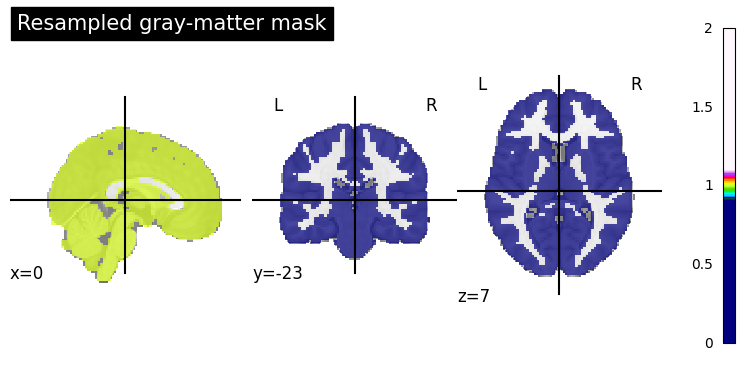

In [7]:
# --------------------------------------------------
# Gray-matter mask in MNI space
# --------------------------------------------------

gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)

gm_mask_resampled = image.resample_to_img(
    gm_mask,
    bold_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

print("GM mask shape:", gm_mask_resampled.shape)
print("BOLD shape:", bold_img.shape[:3])

plotting.plot_roi(
    gm_mask_resampled,
    title="Resampled gray-matter mask",
    display_mode="ortho"
)

In [8]:
# --------------------------------------------------
# Fit item-level GLM
# --------------------------------------------------

fmri_glm = FirstLevelModel(
    t_r=1.0,  # same value as previous GLM if used there
    slice_time_ref=0.5,
    hrf_model="spm + derivative + dispersion",
    drift_model="cosine",
    high_pass=0.01,
    mask_img=gm_mask_resampled,
    smoothing_fwhm=smooth_fwhm,
    standardize=False,
    signal_scaling=0,
    noise_model="ar1",
    minimize_memory=False,
    n_jobs=-1,
)

fmri_glm = fmri_glm.fit(
    run_imgs=bold_img,
    events=glm_events,
    confounds=selected_confounds,
)

design_matrix = fmri_glm.design_matrices_[0]

print("GLM fitted.")
print("Design matrix shape:", design_matrix.shape)
print("\nDesign matrix columns:")
print(design_matrix.columns.tolist()[:50])
print("...")
print(design_matrix.columns.tolist()[-20:])

display(design_matrix.head())

GLM fitted.
Design matrix shape: (1994, 88)

Design matrix columns:
['item_000', 'item_000_derivative', 'item_000_dispersion', 'item_001', 'item_001_derivative', 'item_001_dispersion', 'item_002', 'item_002_derivative', 'item_002_dispersion', 'item_003', 'item_003_derivative', 'item_003_dispersion', 'item_004', 'item_004_derivative', 'item_004_dispersion', 'item_005', 'item_005_derivative', 'item_005_dispersion', 'item_006', 'item_006_derivative', 'item_006_dispersion', 'item_007', 'item_007_derivative', 'item_007_dispersion', 'item_008', 'item_008_derivative', 'item_008_dispersion', 'item_009', 'item_009_derivative', 'item_009_dispersion', 'item_010', 'item_010_derivative', 'item_010_dispersion', 'item_011', 'item_011_derivative', 'item_011_dispersion', 'other', 'other_derivative', 'other_dispersion', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'global_signal', 'csf', 'white_matter', 'drift_1', 'drift_2']
...
['drift_21', 'drift_22', 'drift_23', 'drift_24', 'drift_25',

,item_000,item_000_derivative,item_000_dispersion,item_001,item_001_derivative,item_001_dispersion,item_002,item_002_derivative,item_002_dispersion,item_003,...,drift_31,drift_32,drift_33,drift_34,drift_35,drift_36,drift_37,drift_38,drift_39,constant
0.5,0.0,0.0,3.977972e-18,0.0,0.0,-1.325094e-17,0.0,0.0,1.113122e-17,0.0,...,0.031661,0.031660,0.031660,0.031659,0.031658,0.031658,0.031657,0.031656,0.031655,1.0
1.5,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,...,0.031585,0.031580,0.031574,0.031568,0.031562,0.031556,0.031549,0.031543,0.031536,1.0
2.5,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,...,0.031435,0.031419,0.031403,0.031387,0.031370,0.031352,0.031335,0.031316,0.031297,1.0
3.5,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,...,0.031209,0.031179,0.031147,0.031115,0.031082,0.031048,0.031013,0.030978,0.030941,1.0
4.5,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,...,0.030908,0.030859,0.030807,0.030755,0.030700,0.030644,0.030587,0.030528,0.030467,1.0


In [9]:
# --------------------------------------------------
# Extract one effect-size map per item
# --------------------------------------------------

item_ids = item_meta["item_id"].tolist()

item_beta_imgs = {}

for item_id in item_ids:
    contrast_vec = np.zeros(len(design_matrix.columns))
    contrast_vec[design_matrix.columns.get_loc(item_id)] = 1.0
    
    beta_img = fmri_glm.compute_contrast(
        contrast_vec,
        output_type="effect_size"
    )
    
    item_beta_imgs[item_id] = beta_img

print("Extracted beta maps:", len(item_beta_imgs))
print(list(item_beta_imgs.keys()))

Extracted beta maps: 12
['item_000', 'item_001', 'item_002', 'item_003', 'item_004', 'item_005', 'item_006', 'item_007', 'item_008', 'item_009', 'item_010', 'item_011']


In [10]:
# --------------------------------------------------
# Create ROI masks
# --------------------------------------------------

subcort = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")
subcort_img = subcort.maps
subcort_labels = subcort.labels

subcort_data = subcort_img.get_fdata()

hippocampus_indices = [
    i for i, label in enumerate(subcort_labels)
    if "Hippocampus" in label
]

amygdala_indices = [
    i for i, label in enumerate(subcort_labels)
    if "Amygdala" in label
]

hippocampus_mask = nib.Nifti1Image(
    np.isin(subcort_data, hippocampus_indices).astype("uint8"),
    subcort_img.affine,
    subcort_img.header,
)

amygdala_mask = nib.Nifti1Image(
    np.isin(subcort_data, amygdala_indices).astype("uint8"),
    subcort_img.affine,
    subcort_img.header,
)

cort = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
cort_img = cort.maps
cort_labels = cort.labels

cort_data = cort_img.get_fdata()

parahipp_indices = [
    i for i, label in enumerate(cort_labels)
    if "Parahippocampal" in label
]

parahipp_mask = nib.Nifti1Image(
    np.isin(cort_data, parahipp_indices).astype("uint8"),
    cort_img.affine,
    cort_img.header,
)

print("Hippocampus labels:", [subcort_labels[i] for i in hippocampus_indices])
print("Amygdala labels:", [subcort_labels[i] for i in amygdala_indices])
print("Parahippocampal labels:", [cort_labels[i] for i in parahipp_indices])

[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
Hippocampus labels: ['Left Hippocampus', 'Right Hippocampus']
Amygdala labels: ['Left Amygdala', 'Right Amygdala']
Parahippocampal labels: ['Parahippocampal Gyrus, anterior division', 'Parahippocampal Gyrus, posterior division']


In [11]:
# --------------------------------------------------
# Extract item patterns in one ROI
# --------------------------------------------------

roi_name = "hippocampus"
roi_mask = hippocampus_mask

masker = NiftiMasker(
    mask_img=roi_mask,
    standardize=True,
)

# Fit masker using first beta image
masker.fit(next(iter(item_beta_imgs.values())))

X = []
valid_item_ids = []

for item_id in item_ids:
    pattern = masker.transform(item_beta_imgs[item_id])
    pattern = pattern.ravel()
    
    if np.all(np.isfinite(pattern)):
        X.append(pattern)
        valid_item_ids.append(item_id)

X = np.vstack(X)

rsa_meta = item_meta.set_index("item_id").loc[valid_item_ids].reset_index()

print("ROI:", roi_name)
print("Pattern matrix shape:", X.shape)
print("Metadata shape:", rsa_meta.shape)

display(rsa_meta[["item_id", "memory_label", "event", "encoding_session", "stim_cat"]])

/tmp/ipykernel_2770842/3505451710.py:14: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  masker.fit(next(iter(item_beta_imgs.values())))
/tmp/ipykernel_2770842/3505451710.py:20: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  pattern = masker.transform(item_beta_imgs[item_id])
/tmp/ipykernel_2770842/3505451710.py:20: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  pattern = ma

ROI: hippocampus
Pattern matrix shape: (12, 1391)
Metadata shape: (12, 13)


/tmp/ipykernel_2770842/3505451710.py:20: UserWarning: Standardization of 3D signal has been requested but would lead to zero values. Skipping.
  pattern = masker.transform(item_beta_imgs[item_id])


,item_id,memory_label,event,encoding_session,stim_cat
0,item_000,schema_week,drink_2_e2_8_nr_o_v1_old.jpg,e2,drink
1,item_001,schema_week,drink_7_e2_5_nr_o_v1_old.jpg,e2,drink
2,item_002,true_week,food_2_e1_11_nr_o_v1_old.jpg,e1,food
3,item_003,true_week,food_6_e2_2_nr_o_v1_old.jpg,e2,food
4,item_004,schema_week,maya_4_e2_11_nr_h_v1_old.jpg,e2,maya
5,item_005,true_week,pirate_3_e1_16_nr_h_v1_old.jpg,e1,pirate
6,item_006,schema_week,pirate_5_e1_7_nr_h_v1_old.jpg,e1,pirate
7,item_007,other_wrong_week,pirate_7_e3_1_nr_h_v1_old.jpg,e3,pirate
8,item_008,schema_week,viking_3_e2_1_nr_h_v1_old.jpg,e2,viking
9,item_009,other_wrong_week,wealth_2_e3_2_nr_o_v1_old.jpg,e3,wealth


In [12]:
# --------------------------------------------------
# Cleaner ROI pattern extraction function
# --------------------------------------------------

def extract_item_patterns(item_beta_imgs, item_ids, item_meta, roi_mask, roi_name):
    # Resample ROI once to beta-map space
    first_img = next(iter(item_beta_imgs.values()))
    
    roi_mask_resampled = image.resample_to_img(
        roi_mask,
        first_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    masker = NiftiMasker(
        mask_img=roi_mask_resampled,
        standardize=False,
    )
    
    masker.fit()
    
    X = []
    valid_item_ids = []
    
    for item_id in item_ids:
        pattern = masker.transform(item_beta_imgs[item_id]).ravel()
        
        if np.all(np.isfinite(pattern)) and np.std(pattern) > 0:
            X.append(pattern)
            valid_item_ids.append(item_id)
    
    X = np.vstack(X)
    
    rsa_meta = (
        item_meta
        .set_index("item_id")
        .loc[valid_item_ids]
        .reset_index()
    )
    
    print("ROI:", roi_name)
    print("Pattern matrix shape:", X.shape)
    print("Metadata shape:", rsa_meta.shape)
    print("Memory labels:")
    print(rsa_meta["memory_label"].value_counts())
    
    return X, rsa_meta, roi_mask_resampled


X_hipp, rsa_meta_hipp, hippocampus_mask_resampled = extract_item_patterns(
    item_beta_imgs=item_beta_imgs,
    item_ids=item_ids,
    item_meta=item_meta,
    roi_mask=hippocampus_mask,
    roi_name="hippocampus",
)

display(rsa_meta_hipp[["item_id", "memory_label", "event", "encoding_session", "stim_cat"]])

ROI: hippocampus
Pattern matrix shape: (12, 696)
Metadata shape: (12, 13)
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


,item_id,memory_label,event,encoding_session,stim_cat
0,item_000,schema_week,drink_2_e2_8_nr_o_v1_old.jpg,e2,drink
1,item_001,schema_week,drink_7_e2_5_nr_o_v1_old.jpg,e2,drink
2,item_002,true_week,food_2_e1_11_nr_o_v1_old.jpg,e1,food
3,item_003,true_week,food_6_e2_2_nr_o_v1_old.jpg,e2,food
4,item_004,schema_week,maya_4_e2_11_nr_h_v1_old.jpg,e2,maya
5,item_005,true_week,pirate_3_e1_16_nr_h_v1_old.jpg,e1,pirate
6,item_006,schema_week,pirate_5_e1_7_nr_h_v1_old.jpg,e1,pirate
7,item_007,other_wrong_week,pirate_7_e3_1_nr_h_v1_old.jpg,e3,pirate
8,item_008,schema_week,viking_3_e2_1_nr_h_v1_old.jpg,e2,viking
9,item_009,other_wrong_week,wealth_2_e3_2_nr_o_v1_old.jpg,e3,wealth


item_id,item_000,item_001,item_002,item_003,item_004,item_005,item_006,item_007,item_008,item_009,item_010,item_011
item_id,,,,,,,,,,,,
item_000,1.000000,0.394815,0.474038,0.022368,0.233022,0.392750,0.175702,0.152247,0.456169,0.424314,0.458047,0.440153
item_001,0.394815,1.000000,0.365197,0.139404,0.133729,0.186189,0.014358,0.230789,0.355225,0.340305,0.206890,0.424735
item_002,0.474038,0.365197,1.000000,-0.043740,0.350383,0.458998,0.089266,0.119745,0.406500,0.442214,0.103206,0.464152
item_003,0.022368,0.139404,-0.043740,1.000000,0.160296,0.099564,-0.103170,0.137944,-0.214045,0.055408,0.146125,0.122066
item_004,0.233022,0.133729,0.350383,0.160296,1.000000,0.113608,-0.647010,-0.004425,0.085170,0.202163,0.135361,0.262672
item_005,0.392750,0.186189,0.458998,0.099564,0.113608,1.000000,0.401737,0.521233,0.533128,0.464073,0.543317,0.578025
item_006,0.175702,0.014358,0.089266,-0.103170,-0.647010,0.401737,1.000000,0.348244,0.307547,0.259990,0.158246,0.176419
item_007,0.152247,0.230789,0.119745,0.137944,-0.004425,0.521233,0.348244,1.000000,0.417211,0.342375,0.427311,0.516013
item_008,0.456169,0.355225,0.406500,-0.214045,0.085170,0.533128,0.307547,0.417211,1.000000,0.489862,0.361345,0.561972


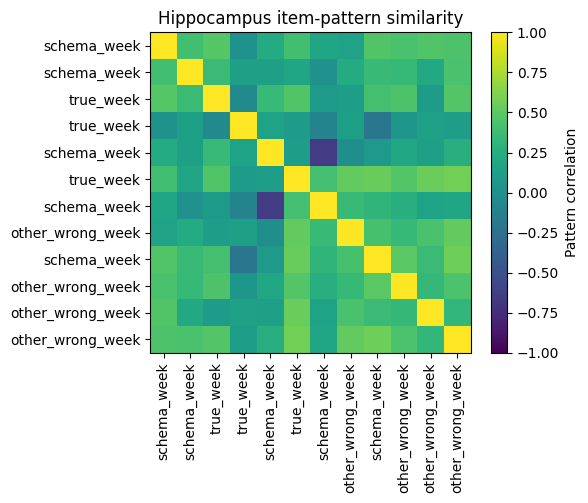

In [13]:
# --------------------------------------------------
# Compute correlation similarity matrix
# --------------------------------------------------

# Correlation distance = 1 - correlation similarity
rdm = squareform(pdist(X_hipp, metric="correlation"))

# Similarity = correlation
sim = 1 - rdm

sim_df = pd.DataFrame(
    sim,
    index=rsa_meta_hipp["item_id"],
    columns=rsa_meta_hipp["item_id"],
)

display(sim_df)

plt.figure(figsize=(6, 5))
plt.imshow(sim, vmin=-1, vmax=1)
plt.colorbar(label="Pattern correlation")
plt.xticks(range(len(rsa_meta_hipp)), rsa_meta_hipp["memory_label"], rotation=90)
plt.yticks(range(len(rsa_meta_hipp)), rsa_meta_hipp["memory_label"])
plt.title("Hippocampus item-pattern similarity")
plt.tight_layout()
plt.show()

,item_i,item_j,label_i,label_j,pair_type,similarity
0,item_000,item_001,schema_week,schema_week,schema_schema,0.394815
1,item_000,item_002,schema_week,true_week,true_schema,0.474038
2,item_000,item_003,schema_week,true_week,true_schema,0.022368
3,item_000,item_004,schema_week,schema_week,schema_schema,0.233022
4,item_000,item_005,schema_week,true_week,true_schema,0.392750
5,item_000,item_006,schema_week,schema_week,schema_schema,0.175702
6,item_000,item_008,schema_week,schema_week,schema_schema,0.456169
7,item_001,item_002,schema_week,true_week,true_schema,0.365197
8,item_001,item_003,schema_week,true_week,true_schema,0.139404
9,item_001,item_004,schema_week,schema_week,schema_schema,0.133729


               count      mean       std       min       25%       50%  \
pair_type                                                                
schema_schema   10.0  0.150873  0.313803 -0.647010  0.097310  0.204362   
true_schema     15.0  0.221177  0.218731 -0.214045  0.101437  0.186189   
true_true        3.0  0.171607  0.258996 -0.043740  0.027912  0.099564   

                    75%       max  
pair_type                          
schema_schema  0.343306  0.456169  
true_schema    0.397243  0.533128  
true_true      0.279281  0.458998  


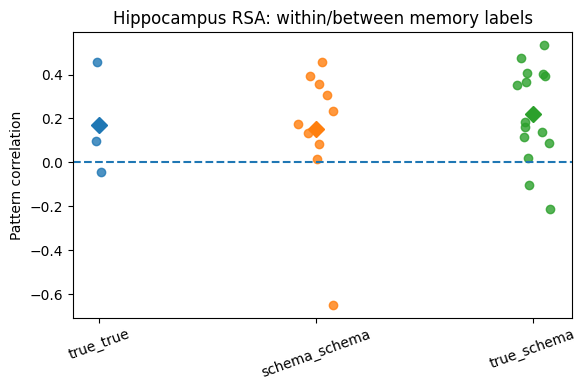

In [14]:
# --------------------------------------------------
# Compare true-true, schema-schema, and true-schema similarities
# --------------------------------------------------

labels = rsa_meta_hipp["memory_label"].values
n = len(labels)

rows = []

for i in range(n):
    for j in range(i + 1, n):
        label_i = labels[i]
        label_j = labels[j]
        
        if label_i not in ["true_week", "schema_week"]:
            continue
        if label_j not in ["true_week", "schema_week"]:
            continue
        
        if label_i == "true_week" and label_j == "true_week":
            pair_type = "true_true"
        elif label_i == "schema_week" and label_j == "schema_week":
            pair_type = "schema_schema"
        else:
            pair_type = "true_schema"
        
        rows.append({
            "item_i": rsa_meta_hipp.loc[i, "item_id"],
            "item_j": rsa_meta_hipp.loc[j, "item_id"],
            "label_i": label_i,
            "label_j": label_j,
            "pair_type": pair_type,
            "similarity": sim[i, j],
        })

pair_df = pd.DataFrame(rows)

display(pair_df)

print(pair_df.groupby("pair_type")["similarity"].describe())

plt.figure(figsize=(6, 4))

pair_types = ["true_true", "schema_schema", "true_schema"]

for i, pair_type in enumerate(pair_types):
    vals = pair_df.loc[pair_df["pair_type"] == pair_type, "similarity"].values
    x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
    plt.scatter(x, vals, alpha=0.8)
    plt.plot(i, vals.mean(), marker="D", markersize=8)

plt.axhline(0, linestyle="--")
plt.xticks(range(len(pair_types)), pair_types, rotation=20)
plt.ylabel("Pattern correlation")
plt.title("Hippocampus RSA: within/between memory labels")
plt.tight_layout()
plt.show()

In [15]:
def compute_roi_rsa_summary(item_beta_imgs, item_ids, item_meta, roi_mask, roi_name):
    X, rsa_meta, roi_mask_resampled = extract_item_patterns(
        item_beta_imgs=item_beta_imgs,
        item_ids=item_ids,
        item_meta=item_meta,
        roi_mask=roi_mask,
        roi_name=roi_name,
    )
    
    rdm = squareform(pdist(X, metric="correlation"))
    sim = 1 - rdm
    
    labels = rsa_meta["memory_label"].values
    n = len(labels)
    
    rows = []
    
    for i in range(n):
        for j in range(i + 1, n):
            label_i = labels[i]
            label_j = labels[j]
            
            if label_i not in ["true_week", "schema_week"]:
                continue
            if label_j not in ["true_week", "schema_week"]:
                continue
            
            if label_i == "true_week" and label_j == "true_week":
                pair_type = "true_true"
            elif label_i == "schema_week" and label_j == "schema_week":
                pair_type = "schema_schema"
            else:
                pair_type = "true_schema"
            
            rows.append({
                "roi": roi_name,
                "item_i": rsa_meta.loc[i, "item_id"],
                "item_j": rsa_meta.loc[j, "item_id"],
                "label_i": label_i,
                "label_j": label_j,
                "pair_type": pair_type,
                "similarity": sim[i, j],
            })
    
    pair_df = pd.DataFrame(rows)
    
    summary = (
        pair_df
        .groupby("pair_type")["similarity"]
        .agg(["count", "mean", "std", "min", "max"])
        .reset_index()
    )
    
    summary["roi"] = roi_name
    
    return {
        "roi": roi_name,
        "X": X,
        "rsa_meta": rsa_meta,
        "sim": sim,
        "rdm": rdm,
        "pair_df": pair_df,
        "summary": summary,
        "mask": roi_mask_resampled,
    }

Visual ROI labels:
22 Lateral Occipital Cortex, superior division
23 Lateral Occipital Cortex, inferior division
24 Intracalcarine Cortex
36 Lingual Gyrus
37 Temporal Fusiform Cortex, anterior division
38 Temporal Fusiform Cortex, posterior division
39 Temporal Occipital Fusiform Cortex
40 Occipital Fusiform Gyrus
48 Occipital Pole
Visual ROI voxels: 29405


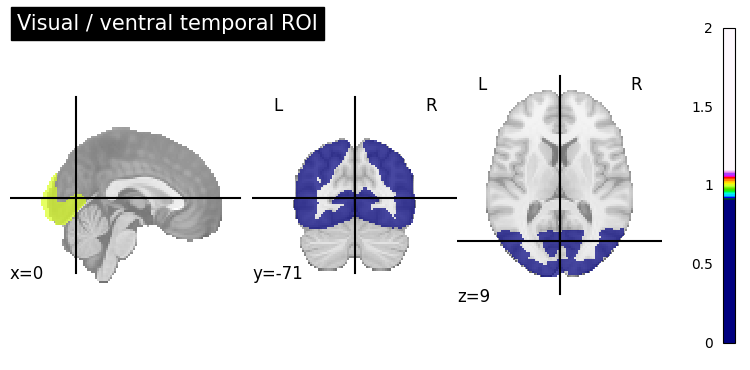

In [16]:
visual_labels = [
    i for i, label in enumerate(cort_labels)
    if (
        "Occipital" in label
        or "Intracalcarine" in label
        or "Lingual" in label
        or "Fusiform" in label
    )
]

visual_mask = nib.Nifti1Image(
    np.isin(cort_data, visual_labels).astype("uint8"),
    cort_img.affine,
    cort_img.header,
)

print("Visual ROI labels:")
for i in visual_labels:
    print(i, cort_labels[i])

print("Visual ROI voxels:", int(np.isin(cort_data, visual_labels).sum()))

plotting.plot_roi(
    visual_mask,
    title="Visual / ventral temporal ROI",
    display_mode="ortho"
)

In [17]:
roi_dict = {
    "hippocampus": hippocampus_mask,
    "amygdala": amygdala_mask,
    "parahippocampal": parahipp_mask,
    "visual_ventral": visual_mask,
}

rsa_results = {}

for roi_name, roi_mask in roi_dict.items():
    print("\n" + "="*60)
    print(roi_name)
    print("="*60)
    
    rsa_results[roi_name] = compute_roi_rsa_summary(
        item_beta_imgs=item_beta_imgs,
        item_ids=item_ids,
        item_meta=item_meta,
        roi_mask=roi_mask,
        roi_name=roi_name,
    )
    
    display(rsa_results[roi_name]["summary"])


hippocampus
ROI: hippocampus
Pattern matrix shape: (12, 696)
Metadata shape: (12, 13)
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


,pair_type,count,mean,std,min,max,roi
0,schema_schema,10,0.150873,0.313803,-0.647010,0.456169,hippocampus
1,true_schema,15,0.221177,0.218731,-0.214045,0.533128,hippocampus
2,true_true,3,0.171607,0.258996,-0.043740,0.458998,hippocampus



amygdala
ROI: amygdala
Pattern matrix shape: (12, 346)
Metadata shape: (12, 13)
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


,pair_type,count,mean,std,min,max,roi
0,schema_schema,10,0.287609,0.346219,-0.495369,0.779938,amygdala
1,true_schema,15,0.424089,0.147774,0.201626,0.618484,amygdala
2,true_true,3,0.739190,0.074815,0.653329,0.790380,amygdala



parahippocampal
ROI: parahippocampal
Pattern matrix shape: (12, 942)
Metadata shape: (12, 13)
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


,pair_type,count,mean,std,min,max,roi
0,schema_schema,10,0.317226,0.352998,-0.536797,0.716732,parahippocampal
1,true_schema,15,0.461159,0.163517,0.139089,0.727014,parahippocampal
2,true_true,3,0.580896,0.156296,0.420905,0.733214,parahippocampal



visual_ventral
ROI: visual_ventral
Pattern matrix shape: (12, 15278)
Metadata shape: (12, 13)
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


,pair_type,count,mean,std,min,max,roi
0,schema_schema,10,0.260852,0.280860,-0.446150,0.553651,visual_ventral
1,true_schema,15,0.357535,0.258257,-0.048486,0.800177,visual_ventral
2,true_true,3,0.248713,0.285849,0.020075,0.569195,visual_ventral


In [18]:
def summarize_rsa_metrics(pair_df):
    means = pair_df.groupby("pair_type")["similarity"].mean()
    counts = pair_df.groupby("pair_type")["similarity"].count()
    
    out = {
        "n_true_true_pairs": counts.get("true_true", 0),
        "n_schema_schema_pairs": counts.get("schema_schema", 0),
        "n_true_schema_pairs": counts.get("true_schema", 0),
        "mean_true_true": means.get("true_true", np.nan),
        "mean_schema_schema": means.get("schema_schema", np.nan),
        "mean_true_schema": means.get("true_schema", np.nan),
    }
    
    out["true_minus_between"] = out["mean_true_true"] - out["mean_true_schema"]
    out["schema_minus_between"] = out["mean_schema_schema"] - out["mean_true_schema"]
    out["true_minus_schema"] = out["mean_true_true"] - out["mean_schema_schema"]
    
    return out


single_subject_metric_rows = []

for roi_name, result in rsa_results.items():
    metrics = summarize_rsa_metrics(result["pair_df"])
    metrics["sub"] = sub
    metrics["roi"] = roi_name
    single_subject_metric_rows.append(metrics)

single_subject_metrics = pd.DataFrame(single_subject_metric_rows)

display(single_subject_metrics)

,n_true_true_pairs,n_schema_schema_pairs,n_true_schema_pairs,mean_true_true,mean_schema_schema,mean_true_schema,true_minus_between,schema_minus_between,true_minus_schema,sub,roi
0,3,10,15,0.171607,0.150873,0.221177,-0.049569,-0.070304,0.020734,sub-P10,hippocampus
1,3,10,15,0.739190,0.287609,0.424089,0.315101,-0.136480,0.451581,sub-P10,amygdala
2,3,10,15,0.580896,0.317226,0.461159,0.119736,-0.143933,0.263669,sub-P10,parahippocampal
3,3,10,15,0.248713,0.260852,0.357535,-0.108822,-0.096683,-0.012139,sub-P10,visual_ventral


In [19]:
def run_subject_post_rsa(
    sub,
    ses="ses-05",
    labels_df=labels_df,
    bids_dir=BIDS_DIR,
    fmriprep_dir=FMRIPREP_DIR,
    roi_dict=roi_dict,
    smooth_fwhm=5.0,
):
    print("\n" + "="*80)
    print(f"Running RSA for {sub} {ses}")
    print("="*80)
    
    # --------------------------------------------------
    # Locate files
    # --------------------------------------------------
    
    bold_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
        )
    )
    
    confound_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
        )
    )
    
    events_candidates = sorted(
        bids_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*events.tsv"
        )
    )
    
    if len(bold_candidates) == 0 or len(confound_candidates) == 0 or len(events_candidates) == 0:
        print("Missing files.")
        return None
    
    bold_path = bold_candidates[0]
    confounds_path = confound_candidates[0]
    events_path = events_candidates[0]
    
    # --------------------------------------------------
    # Load data
    # --------------------------------------------------
    
    bold_img = nib.load(str(bold_path))
    events = pd.read_csv(events_path, sep="\t")
    confounds = pd.read_csv(confounds_path, sep="\t")
    
    # --------------------------------------------------
    # Merge with labels
    # --------------------------------------------------
    
    sub_labels = labels_df.query("sub == @sub").copy()
    
    label_map = sub_labels[[
        "event_filename",
        "stimulus",
        "memory_label",
        "encoding_session",
        "stim_cat",
        "temporal_response",
        "expected_temporal_response",
        "schema_predicted_temporal_response",
        "placement_distance",
        "placement_confidence",
        "temporal_confidence",
    ]].copy()
    
    events_labeled = events.merge(
        label_map,
        left_on="event",
        right_on="event_filename",
        how="left",
    )
    
    rsa_events = events_labeled.dropna(subset=["memory_label"]).copy()
    
    item_counts = (
        rsa_events
        .drop_duplicates("event")
        ["memory_label"]
        .value_counts()
    )
    
    print("Unique item counts:")
    print(item_counts)
    
    if item_counts.get("true_week", 0) < 2 or item_counts.get("schema_week", 0) < 2:
        print("Not enough true/schema items for RSA.")
        return None
    
    # --------------------------------------------------
    # Create item-level regressors
    # --------------------------------------------------
    
    events_item = events_labeled.copy()
    events_item["trial_type"] = "other"
    
    rsa_mask = events_item["memory_label"].notna()
    unique_stimuli = sorted(events_item.loc[rsa_mask, "event"].unique())
    
    stim_to_id = {
        stim: f"item_{i:03d}"
        for i, stim in enumerate(unique_stimuli)
    }
    
    events_item.loc[rsa_mask, "trial_type"] = (
        events_item.loc[rsa_mask, "event"].map(stim_to_id)
    )
    
    glm_events = events_item[["onset", "duration", "trial_type"]].copy()
    
    # --------------------------------------------------
    # Item metadata
    # --------------------------------------------------
    
    item_meta_rows = []
    
    for stim, item_id in stim_to_id.items():
        rows = events_item.loc[events_item["event"] == stim].dropna(subset=["memory_label"])
        first = rows.iloc[0]
        
        item_meta_rows.append({
            "item_id": item_id,
            "event": stim,
            "stimulus": first["stimulus"],
            "memory_label": first["memory_label"],
            "encoding_session": first["encoding_session"],
            "stim_cat": first["stim_cat"],
            "temporal_response": first["temporal_response"],
            "expected_temporal_response": first["expected_temporal_response"],
            "schema_predicted_temporal_response": first["schema_predicted_temporal_response"],
            "placement_distance": first["placement_distance"],
            "placement_confidence": first["placement_confidence"],
            "temporal_confidence": first["temporal_confidence"],
            "n_repetitions": len(rows),
        })
    
    item_meta = pd.DataFrame(item_meta_rows)
    item_ids = item_meta["item_id"].tolist()
    
    # --------------------------------------------------
    # Confounds
    # --------------------------------------------------
    
    confound_cols = [
        "trans_x", "trans_y", "trans_z",
        "rot_x", "rot_y", "rot_z",
        "global_signal", "csf", "white_matter",
    ]
    
    available_confound_cols = [c for c in confound_cols if c in confounds.columns]
    
    selected_confounds = confounds[available_confound_cols].copy()
    selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
    selected_confounds = selected_confounds.fillna(0)
    
    # --------------------------------------------------
    # GM mask
    # --------------------------------------------------
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        bold_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    # --------------------------------------------------
    # Fit item-level GLM
    # --------------------------------------------------
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=bold_img,
        events=glm_events,
        confounds=selected_confounds,
    )
    
    design_matrix = fmri_glm.design_matrices_[0]
    
    # --------------------------------------------------
    # Extract item beta maps
    # --------------------------------------------------
    
    item_beta_imgs = {}
    
    for item_id in item_ids:
        contrast_vec = np.zeros(len(design_matrix.columns))
        contrast_vec[design_matrix.columns.get_loc(item_id)] = 1.0
        
        beta_img = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="effect_size",
        )
        
        item_beta_imgs[item_id] = beta_img
    
    # --------------------------------------------------
    # ROI RSA summaries
    # --------------------------------------------------
    
    metric_rows = []
    
    for roi_name, roi_mask in roi_dict.items():
        result = compute_roi_rsa_summary(
            item_beta_imgs=item_beta_imgs,
            item_ids=item_ids,
            item_meta=item_meta,
            roi_mask=roi_mask,
            roi_name=roi_name,
        )
        
        metrics = summarize_rsa_metrics(result["pair_df"])
        metrics["sub"] = sub
        metrics["roi"] = roi_name
        metrics["n_items"] = len(item_meta)
        metrics["n_true_items"] = item_counts.get("true_week", 0)
        metrics["n_schema_items"] = item_counts.get("schema_week", 0)
        metrics["n_other_items"] = item_counts.get("other_wrong_week", 0)
        
        metric_rows.append(metrics)
    
    metrics_df = pd.DataFrame(metric_rows)
    
    return metrics_df

In [20]:
test_subjects = ["sub-P12", "sub-P13"]

test_results = []

for test_sub in test_subjects:
    res = run_subject_post_rsa(test_sub)
    if res is not None:
        test_results.append(res)

test_metrics = pd.concat(test_results, ignore_index=True)

display(test_metrics)


Running RSA for sub-P12 ses-05
Unique item counts:
memory_label
true_week           8
schema_week         3
other_wrong_week    1
Name: count, dtype: int64
ROI: hippocampus
Pattern matrix shape: (12, 696)
Metadata shape: (12, 13)
Memory labels:
memory_label
true_week           8
schema_week         3
other_wrong_week    1
Name: count, dtype: int64
ROI: amygdala
Pattern matrix shape: (12, 346)
Metadata shape: (12, 13)
Memory labels:
memory_label
true_week           8
schema_week         3
other_wrong_week    1
Name: count, dtype: int64
ROI: parahippocampal
Pattern matrix shape: (12, 942)
Metadata shape: (12, 13)
Memory labels:
memory_label
true_week           8
schema_week         3
other_wrong_week    1
Name: count, dtype: int64
ROI: visual_ventral
Pattern matrix shape: (12, 15278)
Metadata shape: (12, 13)
Memory labels:
memory_label
true_week           8
schema_week         3
other_wrong_week    1
Name: count, dtype: int64

Running RSA for sub-P13 ses-05
Unique item counts:
memory_la

,n_true_true_pairs,n_schema_schema_pairs,n_true_schema_pairs,mean_true_true,mean_schema_schema,mean_true_schema,true_minus_between,schema_minus_between,true_minus_schema,sub,roi,n_items,n_true_items,n_schema_items,n_other_items
0,28,3,24,0.074270,0.336411,0.121566,-0.047297,0.214845,-0.262142,sub-P12,hippocampus,12,8,3,1
1,28,3,24,0.131401,0.279652,0.037447,0.093954,0.242205,-0.148252,sub-P12,amygdala,12,8,3,1
2,28,3,24,0.120032,0.106469,0.105307,0.014725,0.001162,0.013563,sub-P12,parahippocampal,12,8,3,1
3,28,3,24,0.150746,0.194478,0.122686,0.028059,0.071791,-0.043732,sub-P12,visual_ventral,12,8,3,1
4,6,91,56,0.416018,0.554321,0.511515,-0.095498,0.042805,-0.138303,sub-P13,hippocampus,21,4,14,3
5,6,91,56,0.276000,0.486411,0.428021,-0.152021,0.058390,-0.210411,sub-P13,amygdala,21,4,14,3
6,6,91,56,0.466231,0.579311,0.575908,-0.109677,0.003402,-0.113079,sub-P13,parahippocampal,21,4,14,3
7,6,91,56,0.435342,0.502246,0.514120,-0.078778,-0.011875,-0.066904,sub-P13,visual_ventral,21,4,14,3


In [21]:
# all_subjects = sorted(labels_df["sub"].unique())

# print("Subjects:", all_subjects)
# print("N subjects:", len(all_subjects))

# all_results = []

# for this_sub in all_subjects:
#     res = run_subject_post_rsa(this_sub)
    
#     if res is not None:
#         all_results.append(res)

# all_metrics = pd.concat(all_results, ignore_index=True)

# display(all_metrics)

# print("\nSubjects successfully processed:")
# print(sorted(all_metrics["sub"].unique()))
# print("N:", all_metrics["sub"].nunique())

In [22]:
# out_dir = PROJECT_ROOT / "data" / "processed" / "rsa" / "irrelevant_memory"
# out_dir.mkdir(parents=True, exist_ok=True)

# out_path = out_dir / "post_viewing_roi_rsa_metrics.csv"
# all_metrics.to_csv(out_path, index=False)

# print("Saved:", out_path)

In [23]:
# group_rows = []

# for roi in all_metrics["roi"].unique():
#     roi_df = all_metrics.query("roi == @roi").copy()
    
#     for metric in [
#         "true_minus_between",
#         "schema_minus_between",
#         "true_minus_schema",
#     ]:
#         values = roi_df[metric].dropna()
        
#         group_rows.append({
#             "roi": roi,
#             "metric": metric,
#             "n": len(values),
#             "mean": values.mean(),
#             "std": values.std(),
#             "t": ttest_1samp(values, 0).statistic,
#             "p": ttest_1samp(values, 0).pvalue,
#             "wilcoxon_stat": wilcoxon(values).statistic,
#             "wilcoxon_p": wilcoxon(values).pvalue,
#         })

# group_stats = pd.DataFrame(group_rows)

# display(group_stats.sort_values(["metric", "p"]))

In [24]:
# metric_to_plot = "true_minus_between"

# plt.figure(figsize=(8, 4))

# rois = ["hippocampus", "amygdala", "parahippocampal", "visual_ventral"]

# for i, roi in enumerate(rois):
#     vals = all_metrics.query("roi == @roi")[metric_to_plot].dropna().values
#     x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
#     plt.scatter(x, vals, alpha=0.7)
#     plt.plot(i, vals.mean(), marker="D", markersize=8)

# plt.axhline(0, linestyle="--")
# plt.xticks(range(len(rois)), rois, rotation=20)
# plt.ylabel(metric_to_plot)
# plt.title("Post-viewing RSA: true_week within-similarity minus true-schema similarity")
# plt.tight_layout()
# plt.show()

In [25]:
def fit_item_glm_for_session(
    sub,
    ses,
    labels_df,
    bids_dir=BIDS_DIR,
    fmriprep_dir=FMRIPREP_DIR,
    smooth_fwhm=5.0,
):
    # --------------------------------------------------
    # Locate files
    # --------------------------------------------------
    
    bold_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*space-MNI152NLin2009cAsym*desc-preproc_bold.nii.gz"
        )
    )
    
    confound_candidates = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*desc-confounds_timeseries.tsv"
        )
    )
    
    events_candidates = sorted(
        bids_dir.glob(
            f"{sub}/{ses}/func/*task-viewing*events.tsv"
        )
    )
    
    if len(bold_candidates) == 0 or len(confound_candidates) == 0 or len(events_candidates) == 0:
        print(f"Missing files for {sub} {ses}")
        return None
    
    bold_path = bold_candidates[0]
    confounds_path = confound_candidates[0]
    events_path = events_candidates[0]
    
    # --------------------------------------------------
    # Load data
    # --------------------------------------------------
    
    bold_img = nib.load(str(bold_path))
    events = pd.read_csv(events_path, sep="\t")
    confounds = pd.read_csv(confounds_path, sep="\t")
    
    # --------------------------------------------------
    # Merge with memory labels
    # --------------------------------------------------
    
    sub_labels = labels_df.query("sub == @sub").copy()
    
    label_map = sub_labels[[
        "event_filename",
        "stimulus",
        "memory_label",
        "encoding_session",
        "stim_cat",
        "temporal_response",
        "expected_temporal_response",
        "schema_predicted_temporal_response",
        "placement_distance",
        "placement_confidence",
        "temporal_confidence",
    ]].copy()
    
    events_labeled = events.merge(
        label_map,
        left_on="event",
        right_on="event_filename",
        how="left",
    )
    
    rsa_events = events_labeled.dropna(subset=["memory_label"]).copy()
    
    item_counts = (
        rsa_events
        .drop_duplicates("event")
        ["memory_label"]
        .value_counts()
    )
    
    if item_counts.get("true_week", 0) < 2 or item_counts.get("schema_week", 0) < 2:
        print(f"Not enough true/schema items for {sub} {ses}")
        return None
    
    # --------------------------------------------------
    # Create item-level regressors
    # --------------------------------------------------
    
    events_item = events_labeled.copy()
    events_item["trial_type"] = "other"
    
    rsa_mask = events_item["memory_label"].notna()
    unique_stimuli = sorted(events_item.loc[rsa_mask, "event"].unique())
    
    stim_to_id = {
        stim: f"item_{i:03d}"
        for i, stim in enumerate(unique_stimuli)
    }
    
    events_item.loc[rsa_mask, "trial_type"] = (
        events_item.loc[rsa_mask, "event"].map(stim_to_id)
    )
    
    glm_events = events_item[["onset", "duration", "trial_type"]].copy()
    
    # --------------------------------------------------
    # Item metadata
    # --------------------------------------------------
    
    item_meta_rows = []
    
    for stim, item_id in stim_to_id.items():
        rows = events_item.loc[events_item["event"] == stim].dropna(subset=["memory_label"])
        first = rows.iloc[0]
        
        item_meta_rows.append({
            "item_id": item_id,
            "event": stim,
            "stimulus": first["stimulus"],
            "memory_label": first["memory_label"],
            "encoding_session": first["encoding_session"],
            "stim_cat": first["stim_cat"],
            "temporal_response": first["temporal_response"],
            "expected_temporal_response": first["expected_temporal_response"],
            "schema_predicted_temporal_response": first["schema_predicted_temporal_response"],
            "placement_distance": first["placement_distance"],
            "placement_confidence": first["placement_confidence"],
            "temporal_confidence": first["temporal_confidence"],
            "n_repetitions": len(rows),
        })
    
    item_meta = pd.DataFrame(item_meta_rows)
    item_ids = item_meta["item_id"].tolist()
    
    # --------------------------------------------------
    # Confounds
    # --------------------------------------------------
    
    confound_cols = [
        "trans_x", "trans_y", "trans_z",
        "rot_x", "rot_y", "rot_z",
        "global_signal", "csf", "white_matter",
    ]
    
    available_confound_cols = [c for c in confound_cols if c in confounds.columns]
    
    selected_confounds = confounds[available_confound_cols].copy()
    selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
    selected_confounds = selected_confounds.fillna(0)
    
    # --------------------------------------------------
    # GM mask
    # --------------------------------------------------
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        bold_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    # --------------------------------------------------
    # Fit GLM
    # --------------------------------------------------
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=bold_img,
        events=glm_events,
        confounds=selected_confounds,
    )
    
    design_matrix = fmri_glm.design_matrices_[0]
    
    # --------------------------------------------------
    # Extract item beta maps
    # --------------------------------------------------
    
    item_beta_imgs = {}
    
    for item_id in item_ids:
        contrast_vec = np.zeros(len(design_matrix.columns))
        contrast_vec[design_matrix.columns.get_loc(item_id)] = 1.0
        
        beta_img = fmri_glm.compute_contrast(
            contrast_vec,
            output_type="effect_size",
        )
        
        item_beta_imgs[item_id] = beta_img
    
    return {
        "sub": sub,
        "ses": ses,
        "bold_img": bold_img,
        "events_labeled": events_labeled,
        "item_meta": item_meta,
        "item_ids": item_ids,
        "item_beta_imgs": item_beta_imgs,
        "stim_to_id": stim_to_id,
    }

In [26]:
# pre_fit = fit_item_glm_for_session(
#     sub="sub-P10",
#     ses="ses-01",
#     labels_df=labels_df,
# )

# post_fit = fit_item_glm_for_session(
#     sub="sub-P10",
#     ses="ses-05",
#     labels_df=labels_df,
# )

# print("Pre fit:", pre_fit is not None)
# print("Post fit:", post_fit is not None)

# print("\nPre items:")
# display(pre_fit["item_meta"][["item_id", "event", "memory_label"]])

# print("\nPost items:")
# display(post_fit["item_meta"][["item_id", "event", "memory_label"]])

In [27]:
def compute_prepost_same_item_similarity(pre_fit, post_fit, roi_mask, roi_name):
    # --------------------------------------------------
    # Match items by event filename
    # --------------------------------------------------
    
    pre_meta = pre_fit["item_meta"].copy()
    post_meta = post_fit["item_meta"].copy()
    
    common_events = sorted(set(pre_meta["event"]) & set(post_meta["event"]))
    
    pre_meta_common = (
        pre_meta
        .set_index("event")
        .loc[common_events]
        .reset_index()
    )
    
    post_meta_common = (
        post_meta
        .set_index("event")
        .loc[common_events]
        .reset_index()
    )
    
    # --------------------------------------------------
    # Resample ROI once to beta-map space
    # --------------------------------------------------
    
    first_img = next(iter(pre_fit["item_beta_imgs"].values()))
    
    roi_mask_resampled = image.resample_to_img(
        roi_mask,
        first_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    masker = NiftiMasker(
        mask_img=roi_mask_resampled,
        standardize=False,
    )
    
    masker.fit()
    
    rows = []
    
    for event in common_events:
        pre_item_id = pre_meta.loc[pre_meta["event"] == event, "item_id"].iloc[0]
        post_item_id = post_meta.loc[post_meta["event"] == event, "item_id"].iloc[0]
        
        pre_pattern = masker.transform(pre_fit["item_beta_imgs"][pre_item_id]).ravel()
        post_pattern = masker.transform(post_fit["item_beta_imgs"][post_item_id]).ravel()
        
        if np.std(pre_pattern) == 0 or np.std(post_pattern) == 0:
            sim = np.nan
        else:
            sim = np.corrcoef(pre_pattern, post_pattern)[0, 1]
        
        meta_row = pre_meta.loc[pre_meta["event"] == event].iloc[0]
        
        rows.append({
            "sub": pre_fit["sub"],
            "roi": roi_name,
            "event": event,
            "pre_item_id": pre_item_id,
            "post_item_id": post_item_id,
            "memory_label": meta_row["memory_label"],
            "encoding_session": meta_row["encoding_session"],
            "stim_cat": meta_row["stim_cat"],
            "prepost_similarity": sim,
            "placement_distance": meta_row["placement_distance"],
            "placement_confidence": meta_row["placement_confidence"],
            "temporal_confidence": meta_row["temporal_confidence"],
        })
    
    sim_df = pd.DataFrame(rows)
    
    print("ROI:", roi_name)
    print("Common items:", len(common_events))
    print("Memory labels:")
    print(sim_df["memory_label"].value_counts())
    
    return sim_df

In [28]:
# prepost_hipp_p10 = compute_prepost_same_item_similarity(
#     pre_fit=pre_fit,
#     post_fit=post_fit,
#     roi_mask=hippocampus_mask,
#     roi_name="hippocampus",
# )

# display(prepost_hipp_p10)

# print("\nMean pre-post similarity by memory label:")
# display(
#     prepost_hipp_p10
#     .groupby("memory_label")["prepost_similarity"]
#     .describe()
# )

In [29]:
# prepost_p10_rows = []

# for roi_name, roi_mask in roi_dict.items():
#     tmp = compute_prepost_same_item_similarity(
#         pre_fit=pre_fit,
#         post_fit=post_fit,
#         roi_mask=roi_mask,
#         roi_name=roi_name,
#     )
#     prepost_p10_rows.append(tmp)

# prepost_p10 = pd.concat(prepost_p10_rows, ignore_index=True)

# summary_p10 = (
#     prepost_p10
#     .query("memory_label in ['true_week', 'schema_week']")
#     .groupby(["roi", "memory_label"])["prepost_similarity"]
#     .mean()
#     .unstack()
# )

# summary_p10["true_minus_schema"] = summary_p10["true_week"] - summary_p10["schema_week"]

# display(summary_p10)

In [30]:
def run_subject_prepost_rsa(
    sub,
    labels_df=labels_df,
    roi_dict=roi_dict,
    smooth_fwhm=5.0,
):
    print("\n" + "="*80)
    print(f"Running pre-post RSA for {sub}")
    print("="*80)
    
    pre_fit = fit_item_glm_for_session(
        sub=sub,
        ses="ses-01",
        labels_df=labels_df,
        smooth_fwhm=smooth_fwhm,
    )
    
    post_fit = fit_item_glm_for_session(
        sub=sub,
        ses="ses-05",
        labels_df=labels_df,
        smooth_fwhm=smooth_fwhm,
    )
    
    if pre_fit is None or post_fit is None:
        print("Missing pre or post fit.")
        return None
    
    all_rows = []
    
    for roi_name, roi_mask in roi_dict.items():
        sim_df = compute_prepost_same_item_similarity(
            pre_fit=pre_fit,
            post_fit=post_fit,
            roi_mask=roi_mask,
            roi_name=roi_name,
        )
        all_rows.append(sim_df)
    
    item_level_df = pd.concat(all_rows, ignore_index=True)
    
    # Subject-level summary
    summary = (
        item_level_df
        .query("memory_label in ['true_week', 'schema_week']")
        .groupby(["roi", "memory_label"])["prepost_similarity"]
        .mean()
        .unstack()
        .reset_index()
    )
    
    summary["sub"] = sub
    summary["true_minus_schema"] = summary["true_week"] - summary["schema_week"]
    
    counts = (
        item_level_df
        .drop_duplicates(["event"])
        ["memory_label"]
        .value_counts()
    )
    
    summary["n_true_items"] = counts.get("true_week", 0)
    summary["n_schema_items"] = counts.get("schema_week", 0)
    summary["n_other_items"] = counts.get("other_wrong_week", 0)
    summary["n_items"] = counts.sum()
    
    return {
        "summary": summary,
        "item_level": item_level_df,
    }

In [31]:
# test_subjects = ["sub-P10", "sub-P12"]

# test_prepost_results = []
# test_prepost_item_level = []

# for this_sub in test_subjects:
#     res = run_subject_prepost_rsa(this_sub)
    
#     if res is not None:
#         test_prepost_results.append(res["summary"])
#         test_prepost_item_level.append(res["item_level"])

# test_prepost_summary = pd.concat(test_prepost_results, ignore_index=True)
# test_prepost_items = pd.concat(test_prepost_item_level, ignore_index=True)

# display(test_prepost_summary)

In [32]:
all_subjects = sorted(labels_df["sub"].unique())

prepost_results = []
prepost_item_level_results = []

for this_sub in all_subjects:
    res = run_subject_prepost_rsa(this_sub)
    
    if res is not None:
        prepost_results.append(res["summary"])
        prepost_item_level_results.append(res["item_level"])

prepost_summary = pd.concat(prepost_results, ignore_index=True)
prepost_item_level = pd.concat(prepost_item_level_results, ignore_index=True)

display(prepost_summary)

print("\nSubjects successfully processed:")
print(sorted(prepost_summary["sub"].unique()))
print("N:", prepost_summary["sub"].nunique())


Running pre-post RSA for sub-P10
ROI: hippocampus
Common items: 12
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64
ROI: amygdala
Common items: 12
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64
ROI: parahippocampal
Common items: 12
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64
ROI: visual_ventral
Common items: 12
Memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64

Running pre-post RSA for sub-P12
ROI: hippocampus
Common items: 12
Memory labels:
memory_label
true_week           8
schema_week         3
other_wrong_week    1
Name: count, dtype: int64
ROI: amygdala
Common items: 12
Memory labels:
memory_label
true_week           8
schema_week         3
other_wrong_week    1
Name: count, dtype: int64
ROI: pa

/tmp/ipykernel_2770842/4039726643.py:185: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(
/tmp/ipykernel_2770842/4039726643.py:185: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


ROI: hippocampus
Common items: 24
Memory labels:
memory_label
true_week           12
schema_week          7
other_wrong_week     5
Name: count, dtype: int64
ROI: amygdala
Common items: 24
Memory labels:
memory_label
true_week           12
schema_week          7
other_wrong_week     5
Name: count, dtype: int64
ROI: parahippocampal
Common items: 24
Memory labels:
memory_label
true_week           12
schema_week          7
other_wrong_week     5
Name: count, dtype: int64
ROI: visual_ventral
Common items: 24
Memory labels:
memory_label
true_week           12
schema_week          7
other_wrong_week     5
Name: count, dtype: int64

Running pre-post RSA for sub-P34
ROI: hippocampus
Common items: 22
Memory labels:
memory_label
schema_week         11
true_week            7
other_wrong_week     4
Name: count, dtype: int64
ROI: amygdala
Common items: 22
Memory labels:
memory_label
schema_week         11
true_week            7
other_wrong_week     4
Name: count, dtype: int64
ROI: parahippocampal
Co

/tmp/ipykernel_2770842/4039726643.py:185: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


ROI: hippocampus
Common items: 20
Memory labels:
memory_label
schema_week         14
other_wrong_week     3
true_week            3
Name: count, dtype: int64
ROI: amygdala
Common items: 20
Memory labels:
memory_label
schema_week         14
other_wrong_week     3
true_week            3
Name: count, dtype: int64
ROI: parahippocampal
Common items: 20
Memory labels:
memory_label
schema_week         14
other_wrong_week     3
true_week            3
Name: count, dtype: int64
ROI: visual_ventral
Common items: 20
Memory labels:
memory_label
schema_week         14
other_wrong_week     3
true_week            3
Name: count, dtype: int64

Running pre-post RSA for sub-P41


/tmp/ipykernel_2770842/4039726643.py:185: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  fmri_glm = fmri_glm.fit(


ROI: hippocampus
Common items: 22
Memory labels:
memory_label
schema_week         17
true_week            4
other_wrong_week     1
Name: count, dtype: int64
ROI: amygdala
Common items: 22
Memory labels:
memory_label
schema_week         17
true_week            4
other_wrong_week     1
Name: count, dtype: int64
ROI: parahippocampal
Common items: 22
Memory labels:
memory_label
schema_week         17
true_week            4
other_wrong_week     1
Name: count, dtype: int64
ROI: visual_ventral
Common items: 22
Memory labels:
memory_label
schema_week         17
true_week            4
other_wrong_week     1
Name: count, dtype: int64

Running pre-post RSA for sub-P44
ROI: hippocampus
Common items: 23
Memory labels:
memory_label
schema_week         19
true_week            3
other_wrong_week     1
Name: count, dtype: int64
ROI: amygdala
Common items: 23
Memory labels:
memory_label
schema_week         19
true_week            3
other_wrong_week     1
Name: count, dtype: int64
ROI: parahippocampal
Co

memory_label,roi,schema_week,true_week,sub,true_minus_schema,n_true_items,n_schema_items,n_other_items,n_items
0,amygdala,0.220465,-0.011360,sub-P10,-0.231824,3,5,4,12
1,hippocampus,0.111816,-0.037190,sub-P10,-0.149006,3,5,4,12
2,parahippocampal,0.063958,-0.088926,sub-P10,-0.152884,3,5,4,12
3,visual_ventral,-0.084811,-0.154546,sub-P10,-0.069736,3,5,4,12
4,amygdala,-0.029959,0.077355,sub-P12,0.107314,8,3,1,12
...,...,...,...,...,...,...,...,...,...
75,visual_ventral,-0.002809,0.104032,sub-P49,0.106841,5,7,3,15
76,amygdala,0.068645,0.010048,sub-P50,-0.058596,11,4,9,24
77,hippocampus,0.078429,0.024383,sub-P50,-0.054046,11,4,9,24
78,parahippocampal,-0.028891,0.002616,sub-P50,0.031507,11,4,9,24



Subjects successfully processed:
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P18', 'sub-P19', 'sub-P20', 'sub-P21', 'sub-P23', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P41', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P49', 'sub-P50']
N: 20


In [33]:
out_dir = PROJECT_ROOT / "data" / "processed" / "rsa" / "irrelevant_memory"
out_dir.mkdir(parents=True, exist_ok=True)

summary_path = out_dir / "prepost_same_item_roi_rsa_summary.csv"
item_level_path = out_dir / "prepost_same_item_roi_rsa_item_level.csv"

prepost_summary.to_csv(summary_path, index=False)
prepost_item_level.to_csv(item_level_path, index=False)

print("Saved summary:", summary_path)
print("Saved item-level:", item_level_path)

Saved summary: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/rsa/irrelevant_memory/prepost_same_item_roi_rsa_summary.csv
Saved item-level: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/rsa/irrelevant_memory/prepost_same_item_roi_rsa_item_level.csv


In [34]:
group_rows = []

for roi in prepost_summary["roi"].unique():
    roi_df = prepost_summary.query("roi == @roi").copy()
    
    values = roi_df["true_minus_schema"].dropna()
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    group_rows.append({
        "roi": roi,
        "n": len(values),
        "mean_true_minus_schema": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_stat": w_res.statistic,
        "wilcoxon_p": w_res.pvalue,
    })

prepost_group_stats = pd.DataFrame(group_rows)

display(prepost_group_stats.sort_values("p"))

,roi,n,mean_true_minus_schema,std,t,p,wilcoxon_stat,wilcoxon_p
3,visual_ventral,20,0.026009,0.073329,1.586187,0.129200,69.0,0.189348
2,parahippocampal,20,0.008503,0.096651,0.393464,0.698357,100.0,0.869488
0,amygdala,20,-0.005437,0.114721,-0.211931,0.834418,98.0,0.812355
1,hippocampus,20,-0.002272,0.078771,-0.129006,0.898708,87.0,0.521673


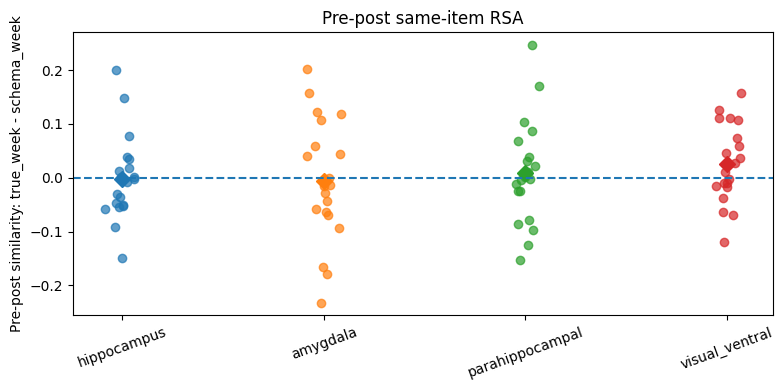

In [35]:
plt.figure(figsize=(8, 4))

rois = ["hippocampus", "amygdala", "parahippocampal", "visual_ventral"]

for i, roi in enumerate(rois):
    vals = prepost_summary.query("roi == @roi")["true_minus_schema"].dropna().values
    x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
    
    plt.scatter(x, vals, alpha=0.7)
    plt.plot(i, vals.mean(), marker="D", markersize=8)

plt.axhline(0, linestyle="--")
plt.xticks(range(len(rois)), rois, rotation=20)
plt.ylabel("Pre-post similarity: true_week - schema_week")
plt.title("Pre-post same-item RSA")
plt.tight_layout()
plt.show()

In [36]:
from scipy.stats import spearmanr

corr_rows = []

for roi in prepost_item_level["roi"].unique():
    roi_df = prepost_item_level.query("roi == @roi").copy()
    
    for var in ["placement_distance", "placement_confidence", "temporal_confidence"]:
        tmp = roi_df[["sub", "event", "memory_label", "prepost_similarity", var]].dropna()
        
        r, p = spearmanr(tmp["prepost_similarity"], tmp[var])
        
        corr_rows.append({
            "roi": roi,
            "variable": var,
            "n_items": len(tmp),
            "spearman_r": r,
            "p": p,
        })

corr_df = pd.DataFrame(corr_rows)

display(corr_df.sort_values("p"))

,roi,variable,n_items,spearman_r,p
1,hippocampus,placement_confidence,416,-0.064064,0.192212
11,visual_ventral,temporal_confidence,416,0.052756,0.283035
0,hippocampus,placement_distance,416,0.043614,0.374917
2,hippocampus,temporal_confidence,416,-0.038089,0.438454
4,amygdala,placement_confidence,416,-0.035610,0.468853
5,amygdala,temporal_confidence,416,-0.033176,0.499798
8,parahippocampal,temporal_confidence,416,-0.030570,0.534082
6,parahippocampal,placement_distance,416,-0.015917,0.746182
3,amygdala,placement_distance,416,0.009043,0.854097
7,parahippocampal,placement_confidence,416,0.008182,0.867859


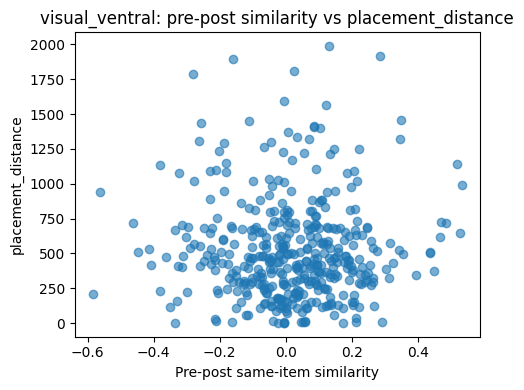

In [37]:
roi = "visual_ventral"
var = "placement_distance"

tmp = prepost_item_level.query("roi == @roi").dropna(
    subset=["prepost_similarity", var]
)

plt.figure(figsize=(5, 4))
plt.scatter(tmp["prepost_similarity"], tmp[var], alpha=0.6)
plt.xlabel("Pre-post same-item similarity")
plt.ylabel(var)
plt.title(f"{roi}: pre-post similarity vs {var}")
plt.tight_layout()
plt.show()

In [38]:
corr_path = out_dir / "prepost_same_item_behavior_correlations.csv"
corr_df.to_csv(corr_path, index=False)

print("Saved:", corr_path)

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/rsa/irrelevant_memory/prepost_same_item_behavior_correlations.csv


In [39]:
# --------------------------------------------------
# Check encoding-session mapping for one subject
# --------------------------------------------------

encoding_ses_map = {
    "e1": "ses-02",
    "e2": "ses-03",
    "e3": "ses-04",
}

sub = "sub-P10"

sub_items = labels_df.query("sub == @sub").copy()

print("Items by encoding session:")
display(
    sub_items
    .groupby(["encoding_session", "memory_label"])
    .size()
    .unstack(fill_value=0)
)

for enc, ses in encoding_ses_map.items():
    print("\n" + "="*70)
    print(enc, "->", ses)
    print("="*70)
    
    events_candidates = sorted(
        BIDS_DIR.glob(
            f"{sub}/{ses}/func/*events.tsv"
        )
    )
    
    print("Event files:")
    for p in events_candidates:
        print(p)
    
    if len(events_candidates) == 0:
        continue
    
    for events_path in events_candidates:
        events_tmp = pd.read_csv(events_path, sep="\t")
        
        print("\nFile:", events_path.name)
        print("Shape:", events_tmp.shape)
        print("Columns:", events_tmp.columns.tolist())
        display(events_tmp.head())
        
        # Try to identify which column contains stimulus filenames
        for col in events_tmp.columns:
            if events_tmp[col].astype(str).str.contains(".jpg", regex=False).any():
                print("Possible stimulus column:", col)
                print(events_tmp[col].dropna().astype(str).head(10).tolist())

Items by encoding session:


memory_label,other_wrong_week,schema_week,true_week
encoding_session,,,
e1,1,1,2
e2,0,4,1
e3,3,0,0



e1 -> ses-02
Event files:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar/sub-P10/ses-02/func/sub-P10_ses-02_task-encoding_run-01_desc-10hz_events.tsv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar/sub-P10/ses-02/func/sub-P10_ses-02_task-encoding_run-01_events.tsv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar/sub-P10/ses-02/func/sub-P10_ses-02_task-encoding_run-02_desc-10hz_events.tsv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar/sub-P10/ses-02/func/sub-P10_ses-02_task-encoding_run-02_events.tsv

File: sub-P10_ses-02_task-encoding_run-01_desc-10hz_events.tsv
Shape: (13440, 4)
Columns: ['onset', 'Player_L_px', 'Player_L_py', 'Player_L_pz']


,onset,Player_L_px,Player_L_py,Player_L_pz
0,0.08637,0.218475,0.113396,0.323898
1,0.18637,0.617775,0.102493,0.898605
2,0.28637,0.896584,0.088089,1.300140
3,0.38637,1.305596,0.056961,1.888809
4,0.48637,1.637013,-0.000183,2.365638



File: sub-P10_ses-02_task-encoding_run-01_events.tsv
Shape: (117, 7)
Columns: ['onset', 'duration', 'event', 'stim', 'trial_type', 'relevant', 'sucess']


...

,onset,duration,event,stim,trial_type,relevant,sucess
0,0.00022,0,Pause OFF;,NaN,NaN,NaN,NaN
1,1.76586,0,Player entered in Checkpoint;0;,NaN,NaN,NaN,NaN
2,2.53465,0,Player exited from Checkpoint;0;,NaN,NaN,NaN,NaN
3,6.15349,0,Player has done path;Path_D_1;x1;,NaN,NaN,NaN,NaN
4,6.61584,0,Player entered in Checkpoint;1;,NaN,NaN,NaN,NaN



File: sub-P10_ses-04_task-encoding_run-02_desc-10hz_events.tsv
Shape: (13204, 4)
Columns: ['onset', 'Player_L_px', 'Player_L_py', 'Player_L_pz']


,onset,Player_L_px,Player_L_py,Player_L_pz
0,0.05692,-0.00658,0.111534,0.004303
1,0.15692,-0.00658,0.111519,0.004303
2,0.25692,-0.00658,0.111527,0.004303
3,0.35692,-0.00658,0.111527,0.004303
4,0.45692,-0.00658,0.111527,0.004303



File: sub-P10_ses-04_task-encoding_run-02_events.tsv
Shape: (102, 7)
Columns: ['onset', 'duration', 'event', 'stim', 'trial_type', 'relevant', 'sucess']


,onset,duration,event,stim,trial_type,relevant,sucess
0,0.00006,0,Pause OFF;,NaN,NaN,NaN,NaN
1,0.01657,0,Player exited from Checkpoint;16;,NaN,NaN,NaN,NaN
2,1.88561,0,Player entered in Checkpoint;0;,NaN,NaN,NaN,NaN
3,2.65406,0,Player exited from Checkpoint;0;,NaN,NaN,NaN,NaN
4,6.26908,0,Player has done path;Path_D_1;x1;,NaN,NaN,NaN,NaN


In [40]:
# --------------------------------------------------
# Inspect non-empty encoding stimulus rows for one subject
# --------------------------------------------------

sub = "sub-P10"

for enc, ses in encoding_ses_map.items():
    print("\n" + "="*80)
    print(f"{enc} -> {ses}")
    print("="*80)
    
    event_files = sorted(
        BIDS_DIR.glob(
            f"{sub}/{ses}/func/*task-encoding_run-*_events.tsv"
        )
    )
    
    # Keep only normal events files, not desc-10hz
    event_files = [p for p in event_files if "desc-10hz" not in p.name]
    
    target_items = labels_df.query(
        "sub == @sub and encoding_session == @enc"
    )["event_filename"].tolist()
    
    print("Target remembered irrelevant items for this encoding session:")
    for x in target_items:
        print("  ", x)
    
    for events_path in event_files:
        events_tmp = pd.read_csv(events_path, sep="\t")
        
        print("\nFile:", events_path.name)
        print("Shape:", events_tmp.shape)
        
        # Rows with non-empty stim/trial_type/relevant
        stim_rows = events_tmp[
            events_tmp["stim"].notna()
            | events_tmp["trial_type"].notna()
            | events_tmp["relevant"].notna()
        ].copy()
        
        print("Stim rows shape:", stim_rows.shape)
        display(stim_rows.head(20))
        
        print("\nUnique trial_type:")
        print(stim_rows["trial_type"].value_counts(dropna=False))
        
        print("\nUnique relevant:")
        print(stim_rows["relevant"].value_counts(dropna=False))
        
        print("\nStim examples:")
        print(stim_rows["stim"].dropna().astype(str).head(30).tolist())
        
        # Try exact/partial matching target item filenames against stim/event columns
        for target in target_items:
            target_no_ext = target.replace(".jpg", "")
            
            match_mask = (
                events_tmp.astype(str).apply(
                    lambda col: col.str.contains(target_no_ext, regex=False, na=False)
                ).any(axis=1)
            )
            
            matches = events_tmp.loc[match_mask]
            
            if len(matches) > 0:
                print(f"\nMATCH for {target}:")
                display(matches)


e1 -> ses-02
Target remembered irrelevant items for this encoding session:
   food_2_e1_11_nr_o_v1_old.jpg
   pirate_5_e1_7_nr_h_v1_old.jpg
   wealth_7_e1_12_nr_o_v1_old.jpg
   pirate_3_e1_16_nr_h_v1_old.jpg

File: sub-P10_ses-02_task-encoding_run-01_events.tsv
Shape: (117, 7)
Stim rows shape: (32, 7)


,onset,duration,event,stim,trial_type,relevant,sucess
5,7.93581,0,Stimuli Presentation;maya_2_e1_1_nr_h_v1_old;h...,maya_2_e1_1_nr_h_v1_old,human,False,NaN
8,14.10307,0,Quiz Response;nr;Success;,NaN,NaN,False,True
13,47.06762,0,Stimuli Presentation;food_5_e1_2_nr_o_v1_old;o...,food_5_e1_2_nr_o_v1_old,object,False,NaN
15,50.98641,0,Quiz Response;nr;Success;,NaN,NaN,False,True
21,231.83487,0,Stimuli Presentation;viking_4_e1_3_r_h_v1_old;...,viking_4_e1_3_r_h_v1_old,human,True,NaN
23,235.82006,0,Quiz Response;re;Success;,NaN,NaN,True,True
27,360.68398,0,Stimuli Presentation;drink_6_e1_4_r_o_v1_old;o...,drink_6_e1_4_r_o_v1_old,object,True,NaN
29,364.56768,0,Quiz Response;re;Success;,NaN,NaN,True,True
35,387.58095,0,Stimuli Presentation;maya_8_e1_5_nr_h_v1_old;h...,maya_8_e1_5_nr_h_v1_old,human,False,NaN
37,391.84941,0,Quiz Response;nr;Success;,NaN,NaN,False,True



Unique trial_type:
trial_type
NaN       16
human      8
object     8
Name: count, dtype: int64

Unique relevant:
relevant
True     17
False    15
Name: count, dtype: int64

Stim examples:
['maya_2_e1_1_nr_h_v1_old', 'food_5_e1_2_nr_o_v1_old', 'viking_4_e1_3_r_h_v1_old', 'drink_6_e1_4_r_o_v1_old', 'maya_8_e1_5_nr_h_v1_old', 'drink_3_e1_6_r_o_v1_old', 'pirate_5_e1_7_nr_h_v1_old', 'wealth_3_e1_8_nr_o_v1_old', 'drink_5_e1_9_r_o_v1_old', 'viking_6_e1_10_r_h_v1_old', 'food_2_e1_11_nr_o_v1_old', 'wealth_7_e1_12_nr_o_v1_old', 'viking_7_e1_13_r_h_v1_old', 'drink_8_e1_14_r_o_v1_old', 'viking_5_e1_15_r_h_v1_old', 'pirate_3_e1_16_nr_h_v1_old']

MATCH for food_2_e1_11_nr_o_v1_old.jpg:


,onset,duration,event,stim,trial_type,relevant,sucess
73,947.96755,0,Stimuli Presentation;food_2_e1_11_nr_o_v1_old;...,food_2_e1_11_nr_o_v1_old,object,False,NaN



MATCH for pirate_5_e1_7_nr_h_v1_old.jpg:


...

,onset,duration,event,stim,trial_type,relevant,sucess
6,7.90068,0,Stimuli Presentation;pirate_7_e3_1_nr_h_v1_old...,pirate_7_e3_1_nr_h_v1_old,human,False,NaN



MATCH for wealth_5_e3_7_nr_o_v1_old.jpg:


,onset,duration,event,stim,trial_type,relevant,sucess
42,601.38269,0,Stimuli Presentation;wealth_5_e3_7_nr_o_v1_old...,wealth_5_e3_7_nr_o_v1_old,object,False,NaN



MATCH for wealth_2_e3_2_nr_o_v1_old.jpg:


,onset,duration,event,stim,trial_type,relevant,sucess
12,42.88395,0,Stimuli Presentation;wealth_2_e3_2_nr_o_v1_old...,wealth_2_e3_2_nr_o_v1_old,object,False,NaN


In [50]:
def fit_encoding_item_glm_for_session(
    sub,
    enc_session,
    labels_df,
    encoding_ses_map=encoding_ses_map,
    bids_dir=BIDS_DIR,
    fmriprep_dir=FMRIPREP_DIR,
    smooth_fwhm=5.0,
    stim_duration=3.0,
):
    ses = encoding_ses_map[enc_session]
    
    print("\n" + "="*80)
    print(f"Encoding GLM: {sub}, {enc_session} -> {ses}")
    print("="*80)
    
    # --------------------------------------------------
    # Items belonging to this encoding session
    # --------------------------------------------------
    
    sub_labels = labels_df.query(
        "sub == @sub and encoding_session == @enc_session"
    ).copy()
    
    if len(sub_labels) == 0:
        print("No labels for this encoding session.")
        return None
    
    target_stims = (
        sub_labels["event_filename"]
        .str.replace(".jpg", "", regex=False)
        .tolist()
    )
    
    print("Target items:", len(target_stims))
    print(sub_labels["memory_label"].value_counts())
    
    # --------------------------------------------------
    # Locate encoding runs
    # --------------------------------------------------
    
    bold_paths = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-encoding_run-*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
        )
    )
    
    confound_paths = sorted(
        fmriprep_dir.glob(
            f"{sub}/{ses}/func/*task-encoding_run-*_desc-confounds_timeseries.tsv"
        )
    )
    
    event_paths = sorted(
        bids_dir.glob(
            f"{sub}/{ses}/func/*task-encoding_run-*_events.tsv"
        )
    )
    
    # Important: exclude 10Hz tracking files and trialsremoved files
    event_paths = [
        p for p in event_paths
        if "desc-10hz" not in p.name
        and "trialsremoved" not in p.name
    ]
    
    print("BOLD runs:", len(bold_paths))
    print("Confound files:", len(confound_paths))
    print("Event files:", len(event_paths))
    
    if len(bold_paths) == 0 or len(confound_paths) == 0 or len(event_paths) == 0:
        print("Missing encoding files.")
        return None
    
    if not (len(bold_paths) == len(confound_paths) == len(event_paths)):
        print("Warning: unequal number of BOLD/confound/event files.")
        print("Will only use matched files from zip().")
    
    print("\nMatched files:")
    for b, c, e in zip(bold_paths, confound_paths, event_paths):
        print("BOLD:   ", b.name)
        print("Conf:   ", c.name)
        print("Events: ", e.name)
        print()
    
    # --------------------------------------------------
    # Build run-wise events and metadata
    # --------------------------------------------------
    
    run_imgs = []
    run_events = []
    run_confounds = []
    
    all_item_meta_rows = []
    
    stim_to_id = {
        stim: f"enc_item_{i:03d}"
        for i, stim in enumerate(sorted(target_stims))
    }
    
    for run_idx, (bold_path, conf_path, events_path) in enumerate(
        zip(bold_paths, confound_paths, event_paths), start=1
    ):
        bold_img = nib.load(str(bold_path))
        events = pd.read_csv(events_path, sep="\t")
        confounds = pd.read_csv(conf_path, sep="\t")
        
        # Keep only stimulus presentation rows
        stim_rows = events[events["stim"].notna()].copy()
        
        # Default all non-target stimuli as other
        glm_events = stim_rows[["onset"]].copy()
        glm_events["duration"] = stim_duration
        glm_events["trial_type"] = "other"
        
        target_mask = stim_rows["stim"].isin(target_stims)
        glm_events.loc[target_mask, "trial_type"] = (
            stim_rows.loc[target_mask, "stim"].map(stim_to_id)
        )
        
        # Confounds
        confound_cols = [
            "trans_x", "trans_y", "trans_z",
            "rot_x", "rot_y", "rot_z",
            "global_signal", "csf", "white_matter",
        ]
        available_confound_cols = [c for c in confound_cols if c in confounds.columns]
        selected_confounds = confounds[available_confound_cols].copy()
        selected_confounds = selected_confounds.replace([np.inf, -np.inf], np.nan)
        selected_confounds = selected_confounds.fillna(0)
        
        run_imgs.append(bold_img)
        run_events.append(glm_events)
        run_confounds.append(selected_confounds)
        
        print(f"\nRun {run_idx}:")
        print("BOLD:", bold_path.name, bold_img.shape)
        print("Events:", events_path.name, glm_events.shape)
        print(glm_events["trial_type"].value_counts().head(20))
    
    # --------------------------------------------------
    # Item metadata
    # --------------------------------------------------
    
    for _, row in sub_labels.iterrows():
        stim_no_ext = row["event_filename"].replace(".jpg", "")
        
        all_item_meta_rows.append({
            "item_id": stim_to_id[stim_no_ext],
            "event": row["event_filename"],
            "stim": stim_no_ext,
            "memory_label": row["memory_label"],
            "encoding_session": row["encoding_session"],
            "stim_cat": row["stim_cat"],
            "placement_distance": row["placement_distance"],
            "placement_confidence": row["placement_confidence"],
            "temporal_confidence": row["temporal_confidence"],
        })
    
    item_meta = (
        pd.DataFrame(all_item_meta_rows)
        .sort_values("item_id")
        .reset_index(drop=True)
    )
    
    item_ids = item_meta["item_id"].tolist()
    
    # --------------------------------------------------
    # GM mask
    # --------------------------------------------------
    
    gm_mask = datasets.load_mni152_gm_mask(threshold=0.2)
    gm_mask_resampled = image.resample_to_img(
        gm_mask,
        run_imgs[0],
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    # --------------------------------------------------
    # Fit multi-run GLM
    # --------------------------------------------------
    
    fmri_glm = FirstLevelModel(
        t_r=1.0,
        slice_time_ref=0.5,
        hrf_model="spm + derivative + dispersion",
        drift_model="cosine",
        high_pass=0.01,
        mask_img=gm_mask_resampled,
        smoothing_fwhm=smooth_fwhm,
        standardize=False,
        signal_scaling=0,
        noise_model="ar1",
        minimize_memory=False,
        n_jobs=-1,
    )
    
    fmri_glm = fmri_glm.fit(
        run_imgs=run_imgs,
        events=run_events,
        confounds=run_confounds,
    )
    
    print("\nEncoding GLM fitted.")
    print("Number of design matrices:", len(fmri_glm.design_matrices_))
    
    # --------------------------------------------------
    # Extract item beta maps safely
    # --------------------------------------------------
    
    item_beta_imgs = {}
    
    for item_id in item_ids:
        contrast_list = []
        n_runs_with_item = 0
        
        for dm in fmri_glm.design_matrices_:
            contrast_vec = np.zeros(len(dm.columns))
            
            if item_id in dm.columns:
                contrast_vec[dm.columns.get_loc(item_id)] = 1.0
                n_runs_with_item += 1
            
            contrast_list.append(contrast_vec)
        
        if n_runs_with_item == 0:
            print(f"Warning: {item_id} not found in any run. Skipping.")
            continue
        
        beta_img = fmri_glm.compute_contrast(
            contrast_list,
            output_type="effect_size",
        )
        
        item_beta_imgs[item_id] = beta_img
    
    # Keep only items for which a beta was extracted
    valid_item_ids = set(item_beta_imgs.keys())
    item_meta = item_meta[item_meta["item_id"].isin(valid_item_ids)].reset_index(drop=True)
    item_ids = item_meta["item_id"].tolist()
    
    print("Extracted encoding beta maps:", len(item_beta_imgs))
    
    return {
        "sub": sub,
        "enc_session": enc_session,
        "ses": ses,
        "item_meta": item_meta,
        "item_ids": item_ids,
        "item_beta_imgs": item_beta_imgs,
        "stim_to_id": stim_to_id,
        "run_imgs": run_imgs,
        "run_events": run_events,
    }

In [51]:
enc_fit_p10_e1 = fit_encoding_item_glm_for_session(
    sub="sub-P10",
    enc_session="e1",
    labels_df=labels_df,
)

print("Encoding fit exists:", enc_fit_p10_e1 is not None)

display(enc_fit_p10_e1["item_meta"])
print("Extracted encoding beta maps:", len(enc_fit_p10_e1["item_beta_imgs"]))


Encoding GLM: sub-P10, e1 -> ses-02
Target items: 4
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Matched files:
BOLD:    sub-P10_ses-02_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Conf:    sub-P10_ses-02_task-encoding_run-01_desc-confounds_timeseries.tsv
Events:  sub-P10_ses-02_task-encoding_run-01_events.tsv

BOLD:    sub-P10_ses-02_task-encoding_run-02_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Conf:    sub-P10_ses-02_task-encoding_run-02_desc-confounds_timeseries.tsv
Events:  sub-P10_ses-02_task-encoding_run-02_events.tsv


Run 1:
BOLD: sub-P10_ses-02_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz (62, 77, 66, 1062)
Events: sub-P10_ses-02_task-encoding_run-01_events.tsv (16, 3)
trial_type
other           12
enc_item_002     1
enc_item_000     1
enc_item_003     1
enc_item_001     1
Name: count, dtype: int64

Run 2:
B

/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(
/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(



Encoding GLM fitted.
Number of design matrices: 2
Extracted encoding beta maps: 4
Encoding fit exists: True


,item_id,event,stim,memory_label,encoding_session,stim_cat,placement_distance,placement_confidence,temporal_confidence
0,enc_item_000,food_2_e1_11_nr_o_v1_old.jpg,food_2_e1_11_nr_o_v1_old,true_week,e1,food,222.2831,23,37
1,enc_item_001,pirate_3_e1_16_nr_h_v1_old.jpg,pirate_3_e1_16_nr_h_v1_old,true_week,e1,pirate,947.1715,38,59
2,enc_item_002,pirate_5_e1_7_nr_h_v1_old.jpg,pirate_5_e1_7_nr_h_v1_old,schema_week,e1,pirate,348.2472,18,35
3,enc_item_003,wealth_7_e1_12_nr_o_v1_old.jpg,wealth_7_e1_12_nr_o_v1_old,other_wrong_week,e1,wealth,822.6772,35,53


Extracted encoding beta maps: 4


In [52]:
def compute_encoding_post_similarity(enc_fit, post_fit, roi_mask, roi_name):
    # --------------------------------------------------
    # Match encoding and post items by event filename
    # --------------------------------------------------
    
    enc_meta = enc_fit["item_meta"].copy()
    post_meta = post_fit["item_meta"].copy()
    
    common_events = sorted(set(enc_meta["event"]) & set(post_meta["event"]))
    
    if len(common_events) == 0:
        print("No common events.")
        return None
    
    # --------------------------------------------------
    # Resample ROI once to encoding beta space
    # --------------------------------------------------
    
    first_img = next(iter(enc_fit["item_beta_imgs"].values()))
    
    roi_mask_resampled = image.resample_to_img(
        roi_mask,
        first_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    masker = NiftiMasker(
        mask_img=roi_mask_resampled,
        standardize=False,
    )
    
    masker.fit()
    
    rows = []
    
    for event in common_events:
        enc_item_id = enc_meta.loc[enc_meta["event"] == event, "item_id"].iloc[0]
        post_item_id = post_meta.loc[post_meta["event"] == event, "item_id"].iloc[0]
        
        enc_pattern = masker.transform(enc_fit["item_beta_imgs"][enc_item_id]).ravel()
        post_pattern = masker.transform(post_fit["item_beta_imgs"][post_item_id]).ravel()
        
        if np.std(enc_pattern) == 0 or np.std(post_pattern) == 0:
            sim = np.nan
        else:
            sim = np.corrcoef(enc_pattern, post_pattern)[0, 1]
        
        meta_row = enc_meta.loc[enc_meta["event"] == event].iloc[0]
        
        rows.append({
            "sub": enc_fit["sub"],
            "roi": roi_name,
            "encoding_session": enc_fit["enc_session"],
            "event": event,
            "enc_item_id": enc_item_id,
            "post_item_id": post_item_id,
            "memory_label": meta_row["memory_label"],
            "stim_cat": meta_row["stim_cat"],
            "encoding_post_similarity": sim,
            "placement_distance": meta_row["placement_distance"],
            "placement_confidence": meta_row["placement_confidence"],
            "temporal_confidence": meta_row["temporal_confidence"],
        })
    
    sim_df = pd.DataFrame(rows)
    
    print("ROI:", roi_name)
    print("Encoding session:", enc_fit["enc_session"])
    print("Common items:", len(common_events))
    print("Memory labels:")
    print(sim_df["memory_label"].value_counts())
    
    return sim_df

In [44]:
post_fit = fit_item_glm_for_session(
    sub="sub-P10",
    ses="ses-05",
    labels_df=labels_df,
)

In [53]:
enc_post_hipp_p10_e1 = compute_encoding_post_similarity(
    enc_fit=enc_fit_p10_e1,
    post_fit=post_fit,
    roi_mask=hippocampus_mask,
    roi_name="hippocampus",
)

display(enc_post_hipp_p10_e1)

display(
    enc_post_hipp_p10_e1
    .groupby("memory_label")["encoding_post_similarity"]
    .describe()
)

ROI: hippocampus
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64


,sub,roi,encoding_session,event,enc_item_id,post_item_id,memory_label,stim_cat,encoding_post_similarity,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,hippocampus,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,0.131472,222.2831,23,37
1,sub-P10,hippocampus,e1,pirate_3_e1_16_nr_h_v1_old.jpg,enc_item_001,item_005,true_week,pirate,-0.020967,947.1715,38,59
2,sub-P10,hippocampus,e1,pirate_5_e1_7_nr_h_v1_old.jpg,enc_item_002,item_006,schema_week,pirate,-0.120586,348.2472,18,35
3,sub-P10,hippocampus,e1,wealth_7_e1_12_nr_o_v1_old.jpg,enc_item_003,item_011,other_wrong_week,wealth,0.169080,822.6772,35,53


,count,mean,std,min,25%,50%,75%,max
memory_label,,,,,,,,
other_wrong_week,1.0,0.169080,NaN,0.169080,0.169080,0.169080,0.169080,0.169080
schema_week,1.0,-0.120586,NaN,-0.120586,-0.120586,-0.120586,-0.120586,-0.120586
true_week,2.0,0.055253,0.107791,-0.020967,0.017143,0.055253,0.093363,0.131472


In [46]:
enc_post_p10_e1_rows = []

for roi_name, roi_mask in roi_dict.items():
    tmp = compute_encoding_post_similarity(
        enc_fit=enc_fit_p10_e1,
        post_fit=post_fit,
        roi_mask=roi_mask,
        roi_name=roi_name,
    )
    enc_post_p10_e1_rows.append(tmp)

enc_post_p10_e1 = pd.concat(enc_post_p10_e1_rows, ignore_index=True)

summary_enc_post_p10_e1 = (
    enc_post_p10_e1
    .query("memory_label in ['true_week', 'schema_week']")
    .groupby(["roi", "memory_label"])["encoding_post_similarity"]
    .mean()
    .unstack()
)

summary_enc_post_p10_e1["true_minus_schema"] = (
    summary_enc_post_p10_e1["true_week"]
    - summary_enc_post_p10_e1["schema_week"]
)

display(summary_enc_post_p10_e1)

ROI: hippocampus
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: amygdala
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: parahippocampal
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: visual_ventral
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64


memory_label,schema_week,true_week,true_minus_schema
roi,,,
amygdala,-0.477091,-0.147975,0.329116
hippocampus,-0.120586,0.055253,0.175838
parahippocampal,-0.257774,-0.071559,0.186216
visual_ventral,-0.066906,-0.189129,-0.122223


In [54]:
def run_subject_encoding_post_rsa(
    sub,
    labels_df=labels_df,
    roi_dict=roi_dict,
    encoding_ses_map=encoding_ses_map,
    smooth_fwhm=5.0,
):
    print("\n" + "="*80)
    print(f"Running encoding-to-post RSA for {sub}")
    print("="*80)
    
    # Fit post-viewing GLM once
    post_fit = fit_item_glm_for_session(
        sub=sub,
        ses="ses-05",
        labels_df=labels_df,
        smooth_fwhm=smooth_fwhm,
    )
    
    if post_fit is None:
        print("No post fit.")
        return None
    
    all_rows = []
    
    for enc_session in ["e1", "e2", "e3"]:
        enc_fit = fit_encoding_item_glm_for_session(
            sub=sub,
            enc_session=enc_session,
            labels_df=labels_df,
            encoding_ses_map=encoding_ses_map,
            smooth_fwhm=smooth_fwhm,
        )
        
        if enc_fit is None:
            continue
        
        for roi_name, roi_mask in roi_dict.items():
            tmp = compute_encoding_post_similarity(
                enc_fit=enc_fit,
                post_fit=post_fit,
                roi_mask=roi_mask,
                roi_name=roi_name,
            )
            
            if tmp is not None:
                all_rows.append(tmp)
    
    if len(all_rows) == 0:
        return None
    
    item_level_df = pd.concat(all_rows, ignore_index=True)
    
    # Subject-level summary
    summary = (
        item_level_df
        .query("memory_label in ['true_week', 'schema_week']")
        .groupby(["roi", "memory_label"])["encoding_post_similarity"]
        .mean()
        .unstack()
        .reset_index()
    )
    
    summary["sub"] = sub
    summary["true_minus_schema"] = summary["true_week"] - summary["schema_week"]
    
    counts = (
        item_level_df
        .drop_duplicates(["event"])
        ["memory_label"]
        .value_counts()
    )
    
    summary["n_true_items"] = counts.get("true_week", 0)
    summary["n_schema_items"] = counts.get("schema_week", 0)
    summary["n_other_items"] = counts.get("other_wrong_week", 0)
    summary["n_items"] = counts.sum()
    
    return {
        "summary": summary,
        "item_level": item_level_df,
    }

In [ ]:
# encpost_p10 = run_subject_encoding_post_rsa("sub-P10")

# display(encpost_p10["summary"])

# print("\nItem-level rows:")
# display(encpost_p10["item_level"].head())

# print("\nItem-level memory labels:")
# print(
#     encpost_p10["item_level"]
#     .drop_duplicates(["event"])
#     ["memory_label"]
#     .value_counts()
# )


Running encoding-to-post RSA for sub-P10

Encoding GLM: sub-P10, e1 -> ses-02
Target items: 4
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Run 1:
BOLD: sub-P10_ses-02_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz (62, 77, 66, 1062)
Events: sub-P10_ses-02_task-encoding_run-01_events.tsv (16, 3)
trial_type
other           12
enc_item_002     1
enc_item_000     1
enc_item_003     1
enc_item_001     1
Name: count, dtype: int64

Run 2:
BOLD: sub-P10_ses-02_task-encoding_run-02_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz (62, 77, 66, 1085)
Events: sub-P10_ses-02_task-encoding_run-02_events.tsv (16, 3)
trial_type
other           12
enc_item_002     1
enc_item_000     1
enc_item_003     1
enc_item_001     1
Name: count, dtype: int64


/tmp/ipykernel_2770842/825826515.py:178: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(
/tmp/ipykernel_2770842/825826515.py:178: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(



Encoding GLM fitted.
Number of design matrices: 2


/tmp/ipykernel_2770842/825826515.py:196: RuntimeWarning: The same contrast will be used for all 2 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  beta_img = fmri_glm.compute_contrast(


ROI: hippocampus
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: amygdala
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: parahippocampal
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: visual_ventral
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64

Encoding GLM: sub-P10, e2 -> ses-03
Target items: 5
memory_label
schema_week    4
true_week      1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Run 1:
BOLD: sub-P10_ses-03_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz (62, 77, 66, 1026)
Events: 

...

ROI: hippocampus
Encoding session: e3
Common items: 3
Memory labels:
memory_label
other_wrong_week    3
Name: count, dtype: int64
ROI: amygdala
Encoding session: e3
Common items: 3
Memory labels:
memory_label
other_wrong_week    3
Name: count, dtype: int64
ROI: parahippocampal
Encoding session: e3
Common items: 3
Memory labels:
memory_label
other_wrong_week    3
Name: count, dtype: int64
ROI: visual_ventral
Encoding session: e3
Common items: 3
Memory labels:
memory_label
other_wrong_week    3
Name: count, dtype: int64


memory_label,roi,schema_week,true_week,sub,true_minus_schema,n_true_items,n_schema_items,n_other_items,n_items
0,amygdala,-0.029522,-0.054908,sub-P10,-0.025386,3,5,4,12
1,hippocampus,0.009464,0.052671,sub-P10,0.043207,3,5,4,12
2,parahippocampal,-0.050661,0.027661,sub-P10,0.078323,3,5,4,12
3,visual_ventral,0.076143,-0.137652,sub-P10,-0.213795,3,5,4,12



Item-level rows:


,sub,roi,encoding_session,event,enc_item_id,post_item_id,memory_label,stim_cat,encoding_post_similarity,placement_distance,placement_confidence,temporal_confidence
0,sub-P10,hippocampus,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,0.131472,222.2831,23,37
1,sub-P10,hippocampus,e1,pirate_3_e1_16_nr_h_v1_old.jpg,enc_item_001,item_005,true_week,pirate,-0.020967,947.1715,38,59
2,sub-P10,hippocampus,e1,pirate_5_e1_7_nr_h_v1_old.jpg,enc_item_002,item_006,schema_week,pirate,-0.120586,348.2472,18,35
3,sub-P10,hippocampus,e1,wealth_7_e1_12_nr_o_v1_old.jpg,enc_item_003,item_011,other_wrong_week,wealth,0.169080,822.6772,35,53
4,sub-P10,amygdala,e1,food_2_e1_11_nr_o_v1_old.jpg,enc_item_000,item_002,true_week,food,-0.403617,222.2831,23,37



Item-level memory labels:
memory_label
schema_week         5
other_wrong_week    4
true_week           3
Name: count, dtype: int64


In [55]:
test_p20_e1 = fit_encoding_item_glm_for_session(
    sub="sub-P20",
    enc_session="e1",
    labels_df=labels_df,
)

print("Fit exists:", test_p20_e1 is not None)

if test_p20_e1 is not None:
    display(test_p20_e1["item_meta"])
    print("Beta maps:", len(test_p20_e1["item_beta_imgs"]))


Encoding GLM: sub-P20, e1 -> ses-02
Target items: 8
memory_label
schema_week         5
other_wrong_week    2
true_week           1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Matched files:
BOLD:    sub-P20_ses-02_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Conf:    sub-P20_ses-02_task-encoding_run-01_desc-confounds_timeseries.tsv
Events:  sub-P20_ses-02_task-encoding_run-01_events.tsv

BOLD:    sub-P20_ses-02_task-encoding_run-02_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Conf:    sub-P20_ses-02_task-encoding_run-02_desc-confounds_timeseries.tsv
Events:  sub-P20_ses-02_task-encoding_run-02_events.tsv


Run 1:
BOLD: sub-P20_ses-02_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz (62, 77, 66, 1642)
Events: sub-P20_ses-02_task-encoding_run-01_events.tsv (15, 3)
trial_type
other           7
enc_item_003    1
enc_item_005    1
enc_item_004    1
enc_item_007    1
enc_item_001    1
enc_item_000    1
enc_

/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(
/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(



Encoding GLM fitted.
Number of design matrices: 2
Extracted encoding beta maps: 8
Fit exists: True


,item_id,event,stim,memory_label,encoding_session,stim_cat,placement_distance,placement_confidence,temporal_confidence
0,enc_item_000,drink_3_e1_11_nr_o_v2_old.jpg,drink_3_e1_11_nr_o_v2_old,schema_week,e1,drink,200.9590,43,99
1,enc_item_001,drink_5_e1_8_nr_o_v2_old.jpg,drink_5_e1_8_nr_o_v2_old,schema_week,e1,drink,530.0057,43,50
2,enc_item_002,food_7_e1_12_nr_o_v2_old.jpg,food_7_e1_12_nr_o_v2_old,other_wrong_week,e1,food,449.9911,50,50
3,enc_item_003,food_8_e1_1_nr_o_v2_old.jpg,food_8_e1_1_nr_o_v2_old,other_wrong_week,e1,food,502.1191,50,50
4,enc_item_004,maya_5_e1_5_nr_h_v2_old.jpg,maya_5_e1_5_nr_h_v2_old,schema_week,e1,maya,468.6139,45,69
5,enc_item_005,maya_7_e1_2_nr_h_v2_old.jpg,maya_7_e1_2_nr_h_v2_old,true_week,e1,maya,570.0751,50,89
6,enc_item_006,viking_5_e1_16_nr_h_v2_old.jpg,viking_5_e1_16_nr_h_v2_old,schema_week,e1,viking,1224.0330,50,50
7,enc_item_007,viking_6_e1_7_nr_h_v2_old.jpg,viking_6_e1_7_nr_h_v2_old,schema_week,e1,viking,717.6583,45,70


Beta maps: 8


In [56]:
all_subjects = sorted(labels_df["sub"].unique())

encpost_results = []
encpost_item_level_results = []

for this_sub in all_subjects:
    res = run_subject_encoding_post_rsa(this_sub)
    
    if res is not None:
        encpost_results.append(res["summary"])
        encpost_item_level_results.append(res["item_level"])

encpost_summary = pd.concat(encpost_results, ignore_index=True)
encpost_item_level = pd.concat(encpost_item_level_results, ignore_index=True)

display(encpost_summary)

print("\nSubjects successfully processed:")
print(sorted(encpost_summary["sub"].unique()))
print("N:", encpost_summary["sub"].nunique())


Running encoding-to-post RSA for sub-P10

Encoding GLM: sub-P10, e1 -> ses-02
Target items: 4
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Matched files:
BOLD:    sub-P10_ses-02_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Conf:    sub-P10_ses-02_task-encoding_run-01_desc-confounds_timeseries.tsv
Events:  sub-P10_ses-02_task-encoding_run-01_events.tsv

BOLD:    sub-P10_ses-02_task-encoding_run-02_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Conf:    sub-P10_ses-02_task-encoding_run-02_desc-confounds_timeseries.tsv
Events:  sub-P10_ses-02_task-encoding_run-02_events.tsv


Run 1:
BOLD: sub-P10_ses-02_task-encoding_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz (62, 77, 66, 1062)
Events: sub-P10_ses-02_task-encoding_run-01_events.tsv (16, 3)
trial_type
other           12
enc_item_002     1
enc_item_000     1
enc_item_003     1
enc_item_001

/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(
/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(



Encoding GLM fitted.
Number of design matrices: 2
Extracted encoding beta maps: 4
ROI: hippocampus
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: amygdala
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: parahippocampal
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64
ROI: visual_ventral
Encoding session: e1
Common items: 4
Memory labels:
memory_label
true_week           2
schema_week         1
other_wrong_week    1
Name: count, dtype: int64

Encoding GLM: sub-P10, e2 -> ses-03
Target items: 5
memory_label
schema_week    4
true_week      1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Matched files:
BOLD:    sub-P10_ses-03_task-

/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(
/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(



Encoding GLM fitted.
Number of design matrices: 2
Extracted encoding beta maps: 7
ROI: hippocampus
Encoding session: e1
Common items: 7
Memory labels:
memory_label
true_week           4
schema_week         2
other_wrong_week    1
Name: count, dtype: int64
ROI: amygdala
Encoding session: e1
Common items: 7
Memory labels:
memory_label
true_week           4
schema_week         2
other_wrong_week    1
Name: count, dtype: int64
ROI: parahippocampal
Encoding session: e1
Common items: 7
Memory labels:
memory_label
true_week           4
schema_week         2
other_wrong_week    1
Name: count, dtype: int64
ROI: visual_ventral
Encoding session: e1
Common items: 7
Memory labels:
memory_label
true_week           4
schema_week         2
other_wrong_week    1
Name: count, dtype: int64

Encoding GLM: sub-P12, e2 -> ses-03
Target items: 5
memory_label
true_week      4
schema_week    1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Matched files:
BOLD:    sub-P12_ses-03_task-

...


Encoding GLM fitted.
Number of design matrices: 2
Extracted encoding beta maps: 8
ROI: hippocampus
Encoding session: e2
Common items: 8
Memory labels:
memory_label
other_wrong_week    3
schema_week         3
true_week           2
Name: count, dtype: int64
ROI: amygdala
Encoding session: e2
Common items: 8
Memory labels:
memory_label
other_wrong_week    3
schema_week         3
true_week           2
Name: count, dtype: int64
ROI: parahippocampal
Encoding session: e2
Common items: 8
Memory labels:
memory_label
other_wrong_week    3
schema_week         3
true_week           2
Name: count, dtype: int64
ROI: visual_ventral
Encoding session: e2
Common items: 8
Memory labels:
memory_label
other_wrong_week    3
schema_week         3
true_week           2
Name: count, dtype: int64

Encoding GLM: sub-P50, e3 -> ses-04
Target items: 8
memory_label
other_wrong_week    5
true_week           2
schema_week         1
Name: count, dtype: int64
BOLD runs: 2
Confound files: 2
Event files: 2

Matched file

/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(
/tmp/ipykernel_2770842/3510616151.py:200: UserWarning: Matrix is singular at working precision, regularizing...
  fmri_glm = fmri_glm.fit(



Encoding GLM fitted.
Number of design matrices: 2
Extracted encoding beta maps: 8
ROI: hippocampus
Encoding session: e3
Common items: 8
Memory labels:
memory_label
other_wrong_week    5
true_week           2
schema_week         1
Name: count, dtype: int64
ROI: amygdala
Encoding session: e3
Common items: 8
Memory labels:
memory_label
other_wrong_week    5
true_week           2
schema_week         1
Name: count, dtype: int64
ROI: parahippocampal
Encoding session: e3
Common items: 8
Memory labels:
memory_label
other_wrong_week    5
true_week           2
schema_week         1
Name: count, dtype: int64
ROI: visual_ventral
Encoding session: e3
Common items: 8
Memory labels:
memory_label
other_wrong_week    5
true_week           2
schema_week         1
Name: count, dtype: int64


memory_label,roi,schema_week,true_week,sub,true_minus_schema,n_true_items,n_schema_items,n_other_items,n_items
0,amygdala,-0.029522,-0.054908,sub-P10,-0.025386,3,5,4,12
1,hippocampus,0.009464,0.052671,sub-P10,0.043207,3,5,4,12
2,parahippocampal,-0.050661,0.027661,sub-P10,0.078323,3,5,4,12
3,visual_ventral,0.076143,-0.137652,sub-P10,-0.213795,3,5,4,12
4,amygdala,0.095773,-0.004527,sub-P12,-0.100300,8,3,1,12
...,...,...,...,...,...,...,...,...,...
75,visual_ventral,-0.103126,0.050940,sub-P49,0.154066,5,7,3,15
76,amygdala,0.070405,-0.130549,sub-P50,-0.200954,11,4,9,24
77,hippocampus,0.310468,-0.041056,sub-P50,-0.351524,11,4,9,24
78,parahippocampal,0.100365,-0.011137,sub-P50,-0.111503,11,4,9,24



Subjects successfully processed:
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P18', 'sub-P19', 'sub-P20', 'sub-P21', 'sub-P23', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P41', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P49', 'sub-P50']
N: 20


In [57]:
encpost_summary_path = out_dir / "encoding_post_same_item_roi_rsa_summary.csv"
encpost_item_level_path = out_dir / "encoding_post_same_item_roi_rsa_item_level.csv"

encpost_summary.to_csv(encpost_summary_path, index=False)
encpost_item_level.to_csv(encpost_item_level_path, index=False)

print("Saved summary:", encpost_summary_path)
print("Saved item-level:", encpost_item_level_path)

Saved summary: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/rsa/irrelevant_memory/encoding_post_same_item_roi_rsa_summary.csv
Saved item-level: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/rsa/irrelevant_memory/encoding_post_same_item_roi_rsa_item_level.csv


In [58]:
encpost_group_rows = []

for roi in encpost_summary["roi"].unique():
    roi_df = encpost_summary.query("roi == @roi").copy()
    
    values = roi_df["true_minus_schema"].dropna()
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    encpost_group_rows.append({
        "roi": roi,
        "n": len(values),
        "mean_true_minus_schema": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_stat": w_res.statistic,
        "wilcoxon_p": w_res.pvalue,
    })

encpost_group_stats = pd.DataFrame(encpost_group_rows)

display(encpost_group_stats.sort_values("p"))

,roi,n,mean_true_minus_schema,std,t,p,wilcoxon_stat,wilcoxon_p
0,amygdala,20,-0.056694,0.100796,-2.515405,0.021045,46.0,0.026642
1,hippocampus,20,-0.025267,0.108067,-1.045630,0.308853,97.0,0.784126
3,visual_ventral,20,-0.022135,0.107195,-0.923483,0.367336,95.0,0.728506
2,parahippocampal,20,-0.012208,0.118904,-0.459163,0.651327,100.0,0.869488


In [59]:
display(encpost_group_stats.sort_values("p"))

,roi,n,mean_true_minus_schema,std,t,p,wilcoxon_stat,wilcoxon_p
0,amygdala,20,-0.056694,0.100796,-2.515405,0.021045,46.0,0.026642
1,hippocampus,20,-0.025267,0.108067,-1.045630,0.308853,97.0,0.784126
3,visual_ventral,20,-0.022135,0.107195,-0.923483,0.367336,95.0,0.728506
2,parahippocampal,20,-0.012208,0.118904,-0.459163,0.651327,100.0,0.869488


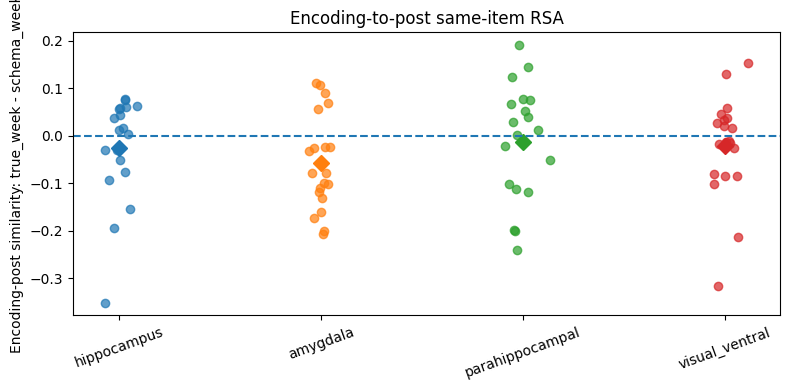

In [60]:
plt.figure(figsize=(8, 4))

rois = ["hippocampus", "amygdala", "parahippocampal", "visual_ventral"]

for i, roi in enumerate(rois):
    vals = encpost_summary.query("roi == @roi")["true_minus_schema"].dropna().values
    x = np.repeat(i, len(vals)) + np.random.normal(0, 0.04, len(vals))
    
    plt.scatter(x, vals, alpha=0.7)
    plt.plot(i, vals.mean(), marker="D", markersize=8)

plt.axhline(0, linestyle="--")
plt.xticks(range(len(rois)), rois, rotation=20)
plt.ylabel("Encoding-post similarity: true_week - schema_week")
plt.title("Encoding-to-post same-item RSA")
plt.tight_layout()
plt.show()

In [61]:
from scipy.stats import spearmanr

encpost_corr_rows = []

for roi in encpost_item_level["roi"].unique():
    roi_df = encpost_item_level.query("roi == @roi").copy()
    
    for var in ["placement_distance", "placement_confidence", "temporal_confidence"]:
        tmp = roi_df[["sub", "event", "memory_label", "encoding_post_similarity", var]].dropna()
        
        r, p = spearmanr(tmp["encoding_post_similarity"], tmp[var])
        
        encpost_corr_rows.append({
            "roi": roi,
            "variable": var,
            "n_items": len(tmp),
            "spearman_r": r,
            "p": p,
        })

encpost_corr_df = pd.DataFrame(encpost_corr_rows)

display(encpost_corr_df.sort_values("p"))

,roi,variable,n_items,spearman_r,p
3,amygdala,placement_distance,401,-0.141149,0.004628
11,visual_ventral,temporal_confidence,401,0.084663,0.090434
9,visual_ventral,placement_distance,401,-0.066927,0.181047
5,amygdala,temporal_confidence,401,0.064250,0.199173
7,parahippocampal,placement_confidence,401,0.060825,0.224232
10,visual_ventral,placement_confidence,401,0.047939,0.338299
1,hippocampus,placement_confidence,401,0.046460,0.353425
4,amygdala,placement_confidence,401,0.032135,0.521098
0,hippocampus,placement_distance,401,0.027338,0.585184
8,parahippocampal,temporal_confidence,401,0.019678,0.694423


In [62]:
filtered_encpost = encpost_summary.query(
    "n_true_items >= 4 and n_schema_items >= 4"
).copy()

display(
    filtered_encpost
    .groupby("roi")["sub"]
    .nunique()
    .reset_index(name="n_subjects")
)

filtered_rows = []

for roi in filtered_encpost["roi"].unique():
    values = (
        filtered_encpost
        .query("roi == @roi")
        ["true_minus_schema"]
        .dropna()
    )
    
    if len(values) < 5:
        continue
    
    t_res = ttest_1samp(values, 0)
    w_res = wilcoxon(values)
    
    filtered_rows.append({
        "roi": roi,
        "n": len(values),
        "mean_true_minus_schema": values.mean(),
        "std": values.std(),
        "t": t_res.statistic,
        "p": t_res.pvalue,
        "wilcoxon_p": w_res.pvalue,
    })

filtered_stats = pd.DataFrame(filtered_rows)
display(filtered_stats.sort_values("p"))

,roi,n_subjects
0,amygdala,13
1,hippocampus,13
2,parahippocampal,13
3,visual_ventral,13


,roi,n,mean_true_minus_schema,std,t,p,wilcoxon_p
0,amygdala,13,-0.048679,0.092663,-1.894135,0.082557,0.094238
1,hippocampus,13,-0.058142,0.120856,-1.734569,0.108404,0.167725
2,parahippocampal,13,0.013760,0.110252,0.450002,0.660730,0.587891
3,visual_ventral,13,0.008208,0.077930,0.379738,0.710775,0.786865


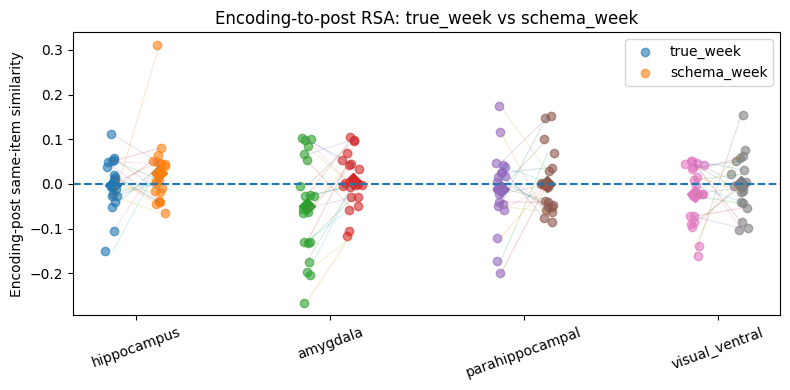

In [63]:
plot_df = encpost_summary.copy()

rois = ["hippocampus", "amygdala", "parahippocampal", "visual_ventral"]

fig, ax = plt.subplots(figsize=(8, 4))

for i, roi in enumerate(rois):
    roi_df = plot_df.query("roi == @roi").copy()
    
    x_true = np.repeat(i - 0.12, len(roi_df)) + np.random.normal(0, 0.02, len(roi_df))
    x_schema = np.repeat(i + 0.12, len(roi_df)) + np.random.normal(0, 0.02, len(roi_df))
    
    ax.scatter(x_true, roi_df["true_week"], alpha=0.6, label="true_week" if i == 0 else None)
    ax.scatter(x_schema, roi_df["schema_week"], alpha=0.6, label="schema_week" if i == 0 else None)
    
    # Mean markers
    ax.plot(i - 0.12, roi_df["true_week"].mean(), marker="D", markersize=8)
    ax.plot(i + 0.12, roi_df["schema_week"].mean(), marker="D", markersize=8)
    
    # Paired subject lines
    for _, row in roi_df.iterrows():
        ax.plot(
            [i - 0.12, i + 0.12],
            [row["true_week"], row["schema_week"]],
            alpha=0.2,
            linewidth=0.8,
        )

ax.axhline(0, linestyle="--")
ax.set_xticks(range(len(rois)))
ax.set_xticklabels(rois, rotation=20)
ax.set_ylabel("Encoding-post same-item similarity")
ax.set_title("Encoding-to-post RSA: true_week vs schema_week")
ax.legend()
plt.tight_layout()
plt.show()

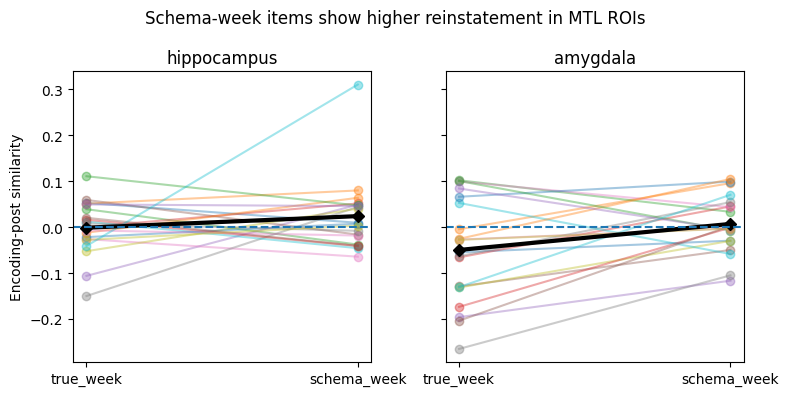

In [64]:
focus_rois = ["hippocampus", "amygdala"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for ax, roi in zip(axes, focus_rois):
    roi_df = encpost_summary.query("roi == @roi").copy()
    
    for _, row in roi_df.iterrows():
        ax.plot(
            [0, 1],
            [row["true_week"], row["schema_week"]],
            marker="o",
            alpha=0.4,
        )
    
    ax.plot(
        [0, 1],
        [roi_df["true_week"].mean(), roi_df["schema_week"].mean()],
        marker="D",
        linewidth=3,
        color="black",
    )
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["true_week", "schema_week"])
    ax.axhline(0, linestyle="--")
    ax.set_title(roi)

axes[0].set_ylabel("Encoding-post similarity")
plt.suptitle("Schema-week items show higher reinstatement in MTL ROIs")
plt.tight_layout()
plt.show()

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/ma/core.py:2892: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


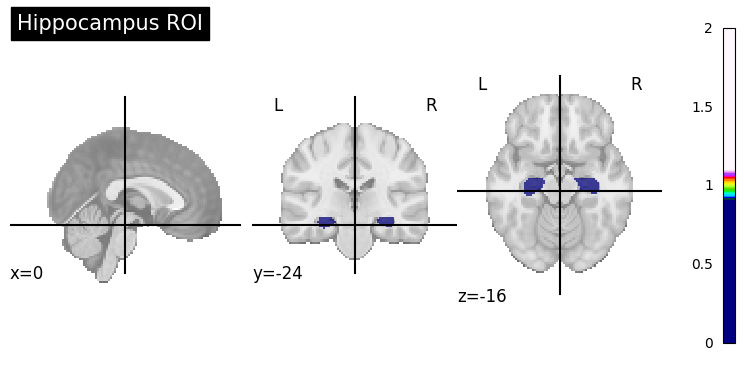

In [65]:
from nilearn import plotting

plotting.plot_roi(
    hippocampus_mask,
    title="Hippocampus ROI",
    display_mode="ortho",
    cut_coords=[0, -24, -16],
)
plt.show()

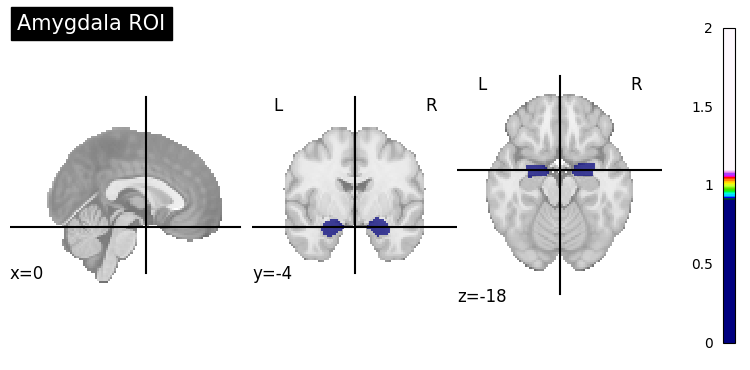

In [66]:
plotting.plot_roi(
    amygdala_mask,
    title="Amygdala ROI",
    display_mode="ortho",
    cut_coords=[0, -4, -18],
)
plt.show()

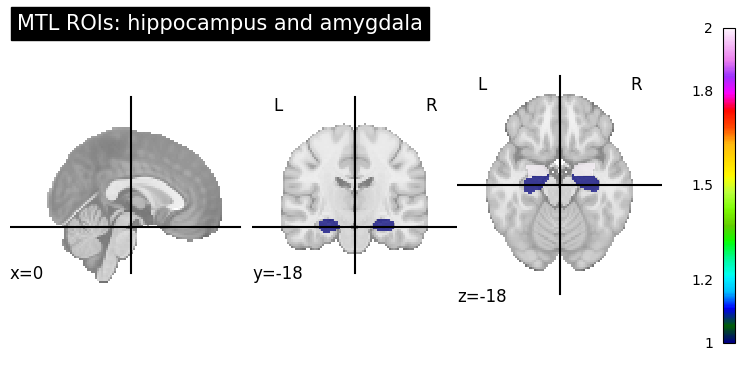

In [67]:
combined_mtl_mask = image.math_img(
    "hipp + 2 * amyg",
    hipp=hippocampus_mask,
    amyg=amygdala_mask,
)

plotting.plot_roi(
    combined_mtl_mask,
    title="MTL ROIs: hippocampus and amygdala",
    display_mode="ortho",
    cut_coords=[0, -18, -18],
)
plt.show()